# Analysis of Factors Affecting Used Car Prices in Saudi Arabia
# تحليل العوامل المؤثرة على أسعار السيارات المستعملة في المملكة العربية السعودية

**Type | النوع:** Individual project | مشروع فردي
**Field | المجال:** Data Science | علم البيانات
**Author | الطالبة:** ِElaf Alyoubi | إيلاف اليوبي
**Start Date |تاريخ البدايه:** sat 19 sep | السبت ١٩ سبنمبر

---

## Project Summary | ملخص المشروع

**EN:** This project analyzes used car listings from the Saudi market to identify the factors that influence price, such as brand, manufacturing year, and mileage. The data is cleaned and explored through visualizations, then used to build a linear regression model. The model lets a user enter a car's brand, year, and mileage and get an estimated price.

**AR:** يحلل هذا المشروع إعلانات السيارات المستعملة في السوق السعودي لمعرفة العوامل المؤثرة على السعر، مثل الماركة وسنة الصنع والممشى. يتم تنظيف البيانات واستكشافها بالرسوم البيانية، ثم بناء نموذج انحدار خطي (Linear Regression) يمكّن المستخدم من إدخال ماركة السيارة وسنة صنعها وممشاها والحصول على سعر متوقع.

---

## Dataset | مصدر البيانات

| | |
|---|---|
| **Name | الاسم** | Saudi Arabia Used Cars Dataset |
| **Author | صاحب الداتا** | Turki Bintaleb |
| **Platform | المنصة** | Kaggle |
| **Link | الرابط** | https://www.kaggle.com/datasets/turkibintalib/saudi-arabia-used-cars-dataset |
| **Original source | المصدر الأصلي** | Listings scraped from the Syarah website (syarah.com) | إعلانات مأخوذة من موقع سيارة |
| **Size | الحجم** | 8,248 rows (listings) × 15 columns |

**EN:** The dataset came as three files: a clean English version, an unclean English version, and an unclean Arabic version (Excel). We use **`UsedCarsSA_Unclean_EN.csv`**, the raw English version, so that the cleaning steps are part of our own work.

**AR:** جاءت الداتا في ثلاثة ملفات: نسخة إنجليزية منظفة، ونسخة إنجليزية غير منظفة، ونسخة عربية غير منظفة (Excel). نستخدم ملف **`UsedCarsSA_Unclean_EN.csv`** (النسخة الإنجليزية الخام) عشان خطوات التنظيف تكون من شغلنا.

### Columns | الأعمدة

Link, Make, Type, Year, Origin, Color, Options, Engine_Size, Fuel_Type, Gear_Type, Condition, Mileage, Region, Price, Negotiable

---

## Data Limitations | ملاحظات على البيانات

- **EN:** Prices are **listing (asking) prices** from an advertising website, not final sale prices.
  **AR:** الأسعار هي **أسعار الإعلانات** في موقع، مو أسعار البيع النهائية.
- **EN:** The dataset was published several years ago, so prices may not match today's market.
  **AR:** الداتا منشورة قبل عدة سنوات، فقد لا تطابق الأسعار السوق الحالي.
- **EN:** Some listings have no numeric price (the text `Negotiable` instead).
  **AR:** بعض الإعلانات ما فيها سعر رقمي (مكتوب `Negotiable` بدله).

---

## Project Steps | خطوات المشروع

1. Load the data | تحميل البيانات
2. Inspect the data | فحص البيانات
3. Clean the data | تنظيف البيانات
4. Visualize and extract insights | الرسوم البيانية والاستنتاجات
5. Build the price prediction model | بناء نموذج توقع السعر
6. Build the `predict_price` function | بناء دالة `predict_price`
7. Streamlit web page (optional) | صفحة ستريمليت (إضافة)

## Tools | الأدوات

Python, pandas, matplotlib, scikit-learn, Google Colab, Streamlit

In [ ]:
import pandas as pd
from google.colab import files

# Upload the file: choose UsedCarsSA_Unclean_EN.csv only
uploaded = files.upload()

# Get the file name automatically
file_name = list(uploaded.keys())[0]

# Read the file into a table called df
df = pd.read_csv(file_name)

print("Data loaded successfully!")
print("File name:", file_name)

Saving UsedCarsSA_Unclean_EN.csv to UsedCarsSA_Unclean_EN.csv
Data loaded successfully!
File name: UsedCarsSA_Unclean_EN.csv


In [ ]:
# Show the first 5 rows
print(df.head())

# Show number of rows and columns
print("Shape:", df.shape)

# Show column names, types, and missing values
print(df.info())

                                                Link      Make     Type  Year  \
0  https://syarah.com/%D9%83%D8%B1%D8%A7%D9%8A%D8...  Chrysler     C300  2018   
1  https://syarah.com/%D9%86%D9%8A%D8%B3%D8%A7%D9...    Nissan   Patrol  2016   
2  https://syarah.com/online/%D9%86%D9%8A%D8%B3%D...    Nissan    Sunny  2019   
3  https://syarah.com/online/%D9%87%D9%88%D9%86%D...   Hyundai  Elantra  2019   
4  https://syarah.com/online/%D9%87%D9%88%D9%86%D...   Hyundai  Elantra  2019   

  Origin   Color    Options  Engine_Size Fuel_Type  Gear_Type Condition  \
0  Saudi   Black       Full          5.7       Gas  Automatic      Used   
1  Saudi   White       Full          4.8       Gas  Automatic      Used   
2  Saudi  Silver   Standard          1.5       Gas  Automatic      Used   
3  Saudi    Grey   Standard          1.6       Gas  Automatic      Used   
4  Saudi  Silver  Semi Full          2.0       Gas  Automatic      Used   

   Mileage  Region       Price  Negotiable  
0   103000  Riyad

# Data Inspection Notes | ملاحظات فحص البيانات

**File | الملف:** `UsedCarsSA_Unclean_EN.csv` (Kaggle: Saudi Arabia Used Cars Dataset, by Turki Bintaleb)
**Size | الحجم:** 8,248 rows (سيارة) × 15 columns (عمود)

**Useful columns | الأعمدة اللي نحتاجها:** Make, Year, Mileage, Price (+ Type, Region, Negotiable for charts)

---

## Problem 1 | المشكلة 1: `Price` is text, not numeric | السعر نص مو رقم

**EN:** The `Price` column has type `object` (text) because some rows contain the word `Negotiable` instead of a number. Pandas gives one type per column, so a single text value turns the whole column into text. This blocks calculations (mean, sorting) and model training.

**AR:** عمود `Price` نوعه نص (`object`) لأن بعض الصفوف مكتوب فيها كلمة `Negotiable` بدل رقم. بايثون يعطي كل عمود نوع واحد، فقيمة نصية وحدة تحوّل العمود كله إلى نص، وهذا يمنع الحسابات (المتوسط، الترتيب) وتدريب النموذج.

**Fix | الحل:**
1. `pd.to_numeric(df["Price"], errors="coerce")`: text becomes NaN (empty) | النص يتحول لخانة فاضية.
2. Drop rows where Price is NaN, because Price is the target the model must predict | نحذف الصفوف اللي سعرها فاضي لأن السعر هو الهدف اللي يتوقعه النموذج.

---

## Problem 2 | المشكلة 2: Missing values | قيم ناقصة

| Column | Missing | Note |
|---|---|---|
| Engine_Size | 2,266 (~27%) | Not used in our model |
| Options | 109 | Not used in our model |
| Origin | 95 | Not used in our model |
| Gear_Type | 74 | Not used in our model |

**EN:** Make, Year, and Mileage have no missing values. Since these are our model inputs, the missing values above do not affect the model.

**AR:** الماركة والسنة والممشى ما فيها أي نقص، وهي مدخلات النموذج، فالنقص في الأعمدة اللي فوق ما يأثر على النموذج.

**Decision | القرار:** No action needed unless we decide to use these columns later | ما نسوي شي إلا لو قررنا نستخدم هذي الأعمدة لاحقاً.

---

## Problem 3 | المشكلة 3: Unneeded columns | أعمدة ما نحتاجها

**EN:** `Link` is the URL of the listing and adds nothing to the analysis or the model.

**AR:** عمود `Link` هو رابط الإعلان وما يفيد التحليل ولا النموذج.

**Fix | الحل:** Keep only the columns we need | نحتفظ بالأعمدة المهمة بس.

---

## Note | ملاحظة: `Negotiable` column (bool) | عمود Negotiable

**EN:** This is a separate column with `True`/`False` values (type `bool`, not text). It says whether the listing's price is negotiable. It is not a problem. Do not confuse it with the text value `Negotiable` inside the `Price` column.

**AR:** هذا عمود مستقل قيمه `True` أو `False` (نوعه `bool` مو نص)، ويقول هل سعر الإعلان قابل للتفاوض. هو مو مشكلة، ولا تخلطينه مع كلمة `Negotiable` اللي داخل عمود `Price`.

**To check | نتأكد منه:** Does the text value in `Price` match `Negotiable == True`? | هل الأسعار اللي قيمتها نص هي نفسها اللي `Negotiable = True`؟

In [ ]:
# Convert Price to numbers; text like "Negotiable" becomes NaN (missing)
price_numeric = pd.to_numeric(df["Price"], errors="coerce")

# How many prices are NOT numbers?
print("Non-numeric prices:", price_numeric.isna().sum())

# What are those text values?
print(df.loc[price_numeric.isna(), "Price"].value_counts())

# How many prices are exactly zero?
print("Zero prices:", (price_numeric == 0).sum())

# How many duplicate rows?
print("Duplicate rows:", df.duplicated().sum())

# Basic statistics for Year and Mileage
print(df[["Year", "Mileage"]].describe())

Non-numeric prices: 2596
Price
Negotiable    2596
Name: count, dtype: int64
Zero prices: 1
Duplicate rows: 20
              Year       Mileage
count  8248.000000  8.248000e+03
mean   2014.014064  1.494128e+05
std       5.935349  3.455258e+05
min    1936.000000  1.000000e+02
25%    2012.000000  3.700000e+04
50%    2016.000000  1.016575e+05
75%    2018.000000  1.955520e+05
max    2022.000000  2.000000e+07


## Check Results | نتائج الفحص

| Check | Result | Decision |
|---|---|---|
| Non-numeric `Price` | 2,596 rows (~31%), all the text `Negotiable` | Drop these rows |
| Zero price | 1 row | Drop |
| Duplicate rows | 20 rows | Drop duplicates |
| `Year` minimum | 1936 (far from the rest, 25% starts at 2012) | To check |
| `Mileage` maximum | 20,000,000 km (impossible) | To check, then choose a cutoff |

**EN:** After dropping rows without a numeric price, about 5,650 cars remain. Mean mileage (~149,000) is much higher than the median (~101,600), which means a few huge values are pulling the mean up (outliers).

**AR:** بعد حذف الصفوف اللي ما فيها سعر رقمي يبقى حوالي 5,650 سيارة. متوسط الممشى (~149,000) أكبر بكثير من الوسيط (~101,600)، يعني فيه قيم ضخمة قليلة ترفع المتوسط (قيم شاذة).

**Limitation | ملاحظة:** The model learns only from listings that show a price, so it may not represent listings marked `Negotiable`. | النموذج يتعلم من الإعلانات اللي فيها سعر فقط، فقد لا يمثل الإعلانات المكتوب فيها `Negotiable`.

In [ ]:
# Cars older than 1990
print("Cars before 1990:", (df["Year"] < 1990).sum())
print(df.loc[df["Year"] < 1990, ["Make", "Type", "Year", "Mileage", "Price"]].head(10))

# The 10 highest mileage values
print("\nTop 10 mileage values:")
print(df["Mileage"].sort_values(ascending=False).head(10))

# Where do mileage values start to look unrealistic?
print("\nMileage percentiles:")
print(df["Mileage"].quantile([0.90, 0.95, 0.99]))

# Does the text "Negotiable" in Price match the Negotiable column?
price_numeric = pd.to_numeric(df["Price"], errors="coerce")
print("\n", pd.crosstab(price_numeric.isna().rename("Price_is_text"), df["Negotiable"]))

Cars before 1990: 65
          Make             Type  Year  Mileage       Price
115     Toyota  Land Cruiser 70  1982   200000  Negotiable
250     Toyota             Dyna  1987  1100000        6000
736        GMC        Behbehani  1984      238       55000
919     Toyota         Cressida  1986   480000  Negotiable
1024    Toyota        Toyota 86  1988   100000        8000
1157      Ford            Other  1982    34000      180000
1237  Mercedes                E  1983   300000  Negotiable
1537    Nissan           Patrol  1989   300000  Negotiable
1643       GMC           Sierra  1979      100  Negotiable
1708   Pontiac       Bonneville  1978   240000       25000

Top 10 mileage values:
7590    20000000
4595     9999999
5202     4900000
4797     4691232
7728     4500000
6789     4430000
7462     4358765
1606     4090000
3503     4010000
5689     4000000
Name: Mileage, dtype: int64

Mileage percentiles:
0.90    300000.0
0.95    378000.0
0.99    600000.0
Name: Mileage, dtype: float64

 Neg

## Outlier & Consistency Results | نتائج فحص القيم الشاذة والتطابق

**Year | السنة**
- **EN:** 65 cars are older than 1990. They are real classic cars (not typos), but they are few (<1%), their prices depend on collector value, and some have suspicious mileage. **Decision:** keep cars from 1990 onward (`MIN_YEAR = 1990`).
- **AR:** فيه 65 سيارة أقدم من 1990. هي سيارات كلاسيكية حقيقية (مو أخطاء كتابة)، لكنها قليلة (أقل من 1%) وأسعارها تعتمد على قيمتها كسيارة نادرة، وبعضها ممشاه مشكوك فيه. **القرار:** نحتفظ بالسيارات من 1990 وما فوق.

**Mileage | الممشى**
- **EN:** The highest values (20,000,000 and 9,999,999 km) are impossible; 9,999,999 looks like a filler number. 99% of cars have mileage of 600,000 km or less. **Decision:** keep mileage up to 600,000 km (`MAX_MILEAGE = 600000`).
- **AR:** أعلى القيم (20,000,000 و9,999,999 كم) مستحيلة، والرقم 9,999,999 شكله رقم تعبئة. 99% من السيارات ممشاها 600,000 كم أو أقل. **القرار:** نحتفظ بالممشى لين 600,000 كم.

**Negotiable column | عمود Negotiable**
- **EN:** It matches the text `Negotiable` in `Price` exactly (2,596 rows True, 5,652 rows False, no exceptions). So it carries no new information, and after removing rows without a price it has a single value. **Decision:** drop the column.
- **AR:** يطابق كلمة `Negotiable` في عمود `Price` تماماً (2,596 صف True و5,652 صف False بدون أي استثناء). يعني ما يعطينا معلومة جديدة، وبعد حذف الصفوف اللي بلا سعر يصير فيه قيمة وحدة. **القرار:** نحذف العمود.

**Duplicates & zero price | المكرر والسعر صفر**
- 20 duplicate rows and 1 zero-price row: drop | 20 صف مكرر وصف واحد سعره صفر: نحذفهم.


In [ ]:
# Settings you can change later
MIN_YEAR = 1990
MAX_MILEAGE = 600000

# Work on a copy, so the original df stays untouched
clean = df.copy()
print("Start:", len(clean))

# 1. Remove duplicate rows
clean = clean.drop_duplicates()
print("After removing duplicates:", len(clean))

# 2. Convert Price to numbers ("Negotiable" becomes NaN), then drop rows without a price
clean["Price"] = pd.to_numeric(clean["Price"], errors="coerce")
clean = clean.dropna(subset=["Price"])
print("After removing rows without a price:", len(clean))

# 3. Remove zero prices
clean = clean[clean["Price"] > 0]
print("After removing zero prices:", len(clean))

# 4. Keep realistic years
clean = clean[clean["Year"] >= MIN_YEAR]
print("After keeping years >=", MIN_YEAR, ":", len(clean))

# 5. Keep realistic mileage
clean = clean[clean["Mileage"] <= MAX_MILEAGE]
print("After keeping mileage <=", MAX_MILEAGE, ":", len(clean))

# 6. Keep only the columns we need
clean = clean[["Make", "Type", "Year", "Mileage", "Region", "Price"]]
clean = clean.reset_index(drop=True)

# Final check
print("\nFinal shape:", clean.shape)
print(clean.info())

# Look at the price range (this is the check we still owe)
print("\nPrice statistics:")
print(clean["Price"].describe().round(0))
print("\n10 lowest prices:")
print(clean["Price"].sort_values().head(10).tolist())
print("10 highest prices:")
print(clean["Price"].sort_values(ascending=False).head(10).tolist())

Start: 8248
After removing duplicates: 8228
After removing rows without a price: 5636
After removing zero prices: 5635
After keeping years >= 1990 : 5607
After keeping mileage <= 600000 : 5572

Final shape: (5572, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Make     5572 non-null   object 
 1   Type     5572 non-null   object 
 2   Year     5572 non-null   int64  
 3   Mileage  5572 non-null   int64  
 4   Region   5572 non-null   object 
 5   Price    5572 non-null   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 261.3+ KB
None

Price statistics:
count       5572.0
mean       78979.0
std        76305.0
min            1.0
25%        35000.0
50%        58000.0
75%        95000.0
max      1150000.0
Name: Price, dtype: float64

10 lowest prices:
[1.0, 500.0, 850.0, 877.0, 884.0, 950.0, 988.0, 993.0, 1000.0, 1002.0]
10 highest pric

## Cleaning Results | نتائج التنظيف

| Step | Rows left | Removed |
|---|---|---|
| Start | 8,248 | |
| Remove duplicates | 8,228 | 20 |
| Remove rows without a numeric price | 5,636 | 2,592 |
| Remove zero price | 5,635 | 1 |
| Keep Year >= 1990 | 5,607 | 28 |
| Keep Mileage <= 600,000 | 5,572 | 35 |

**EN:** 5,572 cars remain (about 32% of the file was removed, mostly listings with `Negotiable` instead of a price). We kept 6 columns: Make, Type, Year, Mileage, Region, Price. None of them has missing values.

**AR:** بقي 5,572 سيارة (انحذف حوالي 32% من الملف، أغلبه إعلانات مكتوب فيها `Negotiable` بدل السعر). احتفظنا بـ 6 أعمدة: Make وType وYear وMileage وRegion وPrice، وما فيها أي قيم ناقصة.

**Price check | فحص الأسعار**
- **EN:** Mean (~78,979) is higher than the median (58,000) because a few expensive cars pull it up. The lowest prices look suspicious (1, 500, 850, 877 SAR). We inspect them before choosing a minimum price.
- **AR:** المتوسط (~78,979) أكبر من الوسيط (58,000) لأن السيارات الغالية القليلة ترفعه. أقل الأسعار مشبوهة (1 و500 و850 و877 ريال)، فنفحصها قبل ما نحدد حد أدنى للسعر.

**Still to check | لسا نتأكد منه**
- [ ] Choose `MIN_PRICE` after inspecting the cheapest cars | تحديد الحد الأدنى للسعر بعد فحص أرخص السيارات
- [ ] Save the clean data to a CSV file | حفظ البيانات النظيفة في ملف CSV

In [ ]:
# How many cars are below different price levels?
for limit in [1000, 2000, 3000, 5000, 10000]:
    print("Price <", limit, ":", (clean["Price"] < limit).sum())

# The cheapest 20 cars, with details
print("\nCheapest 20 cars:")
print(clean.sort_values("Price").head(20)[["Make", "Type", "Year", "Mileage", "Price"]])

# The 10 most expensive cars, with details
print("\nMost expensive 10 cars:")
print(clean.sort_values("Price", ascending=False).head(10)[["Make", "Type", "Year", "Mileage", "Price"]])

Price < 1000 : 8
Price < 2000 : 64
Price < 3000 : 85
Price < 5000 : 95
Price < 10000 : 146

Cheapest 20 cars:
            Make     Type  Year  Mileage   Price
5562         GMC    Yukon  2019    50000     1.0
4995     Genesis      G80  2018   170000   500.0
5332      Toyota    Yaris  2018   100000   850.0
1846  Mitsubishi  Attrage  2019    41000   877.0
2893         Kia      Rio  2019    55500   884.0
5112      Toyota    Yaris  2019    85000   950.0
1415          MG        5  2020    41000   988.0
5348     Hyundai  Elantra  2019    89000   993.0
2484         GMC    Yukon  2021     4000  1000.0
3323      Toyota  Corolla  2020    48563  1002.0
2852     Hyundai   Sonata  2020     7000  1010.0
1801     Hyundai  Elantra  2020    27000  1010.0
4908      Toyota  Corolla  2020    14000  1013.0
5356      Toyota    Yaris  2018   169000  1046.0
2222     Hyundai   Accent  2020    35000  1066.0
5518      Toyota  Corolla  2020    26000  1086.0
4510     Renault   Duster  2017   106000  1128.0
1278    

## Price Outlier Results | نتائج فحص الأسعار الشاذة

**Low prices | الأسعار المنخفضة**
- **EN:** 95 cars were priced below 5,000 SAR: 87 are from 2015 or newer and only 8 are from 2014 or older. The 20 cheapest cars are all modern (2017-2021) and priced between 1 and 1,158 SAR, which is impossible (e.g. a 2019 GMC Yukon at 1 SAR). The cause is unconfirmed; possibly installment or down-payment amounts entered instead of the full price. The count drops sharply above 3,000 SAR (85 cars below 3,000, only 10 more between 3,000 and 5,000).
- **AR:** فيه 95 سيارة سعرها أقل من 5,000 ريال: 87 منها موديل 2015 وأحدث، و8 فقط موديل 2014 وأقدم. أرخص 20 سيارة كلها حديثة (2017 إلى 2021) وأسعارها بين 1 و1,158 ريال، وهذا مستحيل (مثلاً GMC Yukon موديل 2019 بسعر 1 ريال). السبب غير مؤكد، ويمكن إن مبلغ القسط أو الدفعة الأولى انكتب بدل السعر الكامل. العدد ينزل بسرعة فوق 3,000 (85 سيارة تحت 3,000 وبس 10 بين 3,000 و5,000).

- **EN:** A fixed limit would be unfair, because seven older cars (1995-2008, mostly high mileage) have realistic prices between 3,000 and 4,500 SAR (Chevrolet Caprice 1995, Suburban 1997, Ford Victoria 2001, Expedition 2003, Lumina 2006, Aveo 2008, Hyundai Accent 2008). So we compared each car with cars of the same Make and Year: 84 of the 95 were priced at 6% or less of the median (e.g. a 2020 Toyota Corolla at 1,002 SAR vs. a median of 113,000 SAR). We also checked mileage: 81 of the 84 removed cars that have comparable cars were priced below 10% of the cheapest comparable car. The closest case was a 2016 Ford Mustang (184,000 km) at 3,049 SAR vs. 19,000 SAR. Most removed cars have low mileage (median 47,000 km), so high mileage does not explain their prices.
- **AR:** الحد الثابت يظلم بعض السيارات، لأن سبع سيارات قديمة (1995 إلى 2008، أغلبها ممشاها عالي) أسعارها معقولة بين 3,000 و4,500 ريال (Chevrolet Caprice 1995 وSuburban 1997 وFord Victoria 2001 وExpedition 2003 وLumina 2006 وAveo 2008 وHyundai Accent 2008). فقارنّا كل سيارة بالسيارات اللي نفس الماركة ونفس السنة: 84 من الـ 95 سعرها 6% أو أقل من الوسيط (مثلاً Toyota Corolla موديل 2020 بسعر 1,002 ريال ووسيط مثيلاتها 113,000 ريال). وفحصنا الممشى كمان: 81 من 84 سيارة محذوفة لها سيارات للمقارنة كان سعرها أقل من 10% من أرخص مثيل. وأقرب حالة كانت Ford Mustang 2016 (ممشاها 184,000 كم) بسعر 3,049 ريال مقابل 19,000 ريال. أغلب المحذوفات ممشاها قليل (الوسيط 47,000 كم)، فالممشى العالي ما يفسر أسعارها.

- **EN:** **Decision:** remove a car only if its price is below 5,000 SAR **and** its year is 2010 or newer (`MIN_PRICE = 5000`, `MODERN_YEAR = 2010`). This removed 88 cars and kept the 7 old cars, leaving 5,484 cars. The removed rows are saved with the reason in `removed_low_price_rows.csv`. We removed instead of correcting because no single factor fixes all the prices, and any correction would be a guess. The year threshold is a judgment call; on this data any year from 2010 to 2014 gives the same result. Four removed cars (Passat, Wingle, Megane, Other) have no comparable car in the data, so they were judged by year and price only. The prices are implausible, but we cannot prove they are errors.
- **AR:** **القرار:** نحذف السيارة فقط إذا كان سعرها أقل من 5,000 ريال **و**سنة صنعها 2010 أو أحدث (`MIN_PRICE = 5000` و`MODERN_YEAR = 2010`). حذفنا 88 سيارة وأبقينا السبع القديمة، وبقي 5,484 سيارة. الصفوف المحذوفة محفوظة مع السبب في `removed_low_price_rows.csv`. حذفنا وما صححنا لأنه ما فيه معامل واحد يصلح كل الأسعار، وأي تصحيح يكون تخمين. سنة الفصل اجتهاد، وعلى هذي البيانات أي سنة من 2010 إلى 2014 تعطي نفس النتيجة. أربع سيارات محذوفة (Passat وWingle وMegane وOther) ما لها مثيل في البيانات، فحكمنا عليها بالسنة والسعر فقط. الأسعار غير منطقية، لكن ما نقدر نثبت إنها أخطاء.

**High prices | الأسعار العالية**
- **EN:** The most expensive cars (Mercedes G-Class, Bentley Bentayga, Rolls-Royce Ghost, Range Rover) have realistic prices for luxury cars. **Decision:** keep them. One oddity: a "Bentley Arnage 2020" (this model ended production years earlier), probably a wrong `Type` label; we do not use `Type` in the model.
- **AR:** أغلى السيارات (مرسيدس G وبنتلي بنتايغا ورولز رويس غوست ورنج روفر) أسعارها منطقية للسيارات الفاخرة. **القرار:** نحتفظ فيها. ملاحظة: "Bentley Arnage 2020" غريبة (الطراز توقف إنتاجه قبلها بسنين)، غالباً اسم الطراز مكتوب غلط، وما نستخدم `Type` في النموذج.


In [ ]:
# Compare each car with similar cars (same Make and Year)
check = clean.copy()
check["group_size"] = check.groupby(["Make", "Year"])["Price"].transform("count")
check["group_median"] = check.groupby(["Make", "Year"])["Price"].transform("median")
check["ratio"] = (check["Price"] / check["group_median"]).round(2)

# All cars priced under 5,000, sorted from the most suspicious
low = check[check["Price"] < 5000].sort_values("ratio")
print("Cars under 5,000:", len(low))

# Quick view: how many per production-year range
print(pd.cut(low["Year"], [1989, 2004, 2009, 2014, 2019, 2022]).value_counts().sort_index())

# Full list
print(low[["Make", "Type", "Year", "Mileage", "Price", "group_size", "group_median", "ratio"]].to_string())

Cars under 5,000: 95
Year
(1989, 2004]     4
(2004, 2009]     3
(2009, 2014]     1
(2014, 2019]    46
(2019, 2022]    41
Name: count, dtype: int64
            Make             Type  Year  Mileage   Price  group_size  group_median  ratio
5562         GMC            Yukon  2019    50000     1.0           4      147500.0   0.00
2116      Toyota            Hilux  2021    37000  1723.0          34      160250.0   0.01
2835      Nissan           Patrol  2021     5000  3772.0           3      258000.0   0.01
2484         GMC            Yukon  2021     4000  1000.0           6      183500.0   0.01
4482      Toyota            Camry  2020    38000  1364.0         100      113000.0   0.01
3591       Mazda              CX5  2021     5500  1262.0           6      111500.0   0.01
3323      Toyota          Corolla  2020    48563  1002.0         100      113000.0   0.01
3320      Toyota            Camry  2021    10000  1519.0          34      160250.0   0.01
4995     Genesis              G80  2018   1

## Comparison with Similar Cars | المقارنة بالسيارات المشابهة

**What this cell does | وش سوت الخلية**
- **EN:** For every car, the cell calculated the median price of cars with the same Make and Year (`group_median`), then the ratio `ratio = Price / group_median`. A ratio of 0.02 means the car costs 2% of the typical price of similar cars. It then listed all cars priced below 5,000 SAR, sorted from the lowest ratio (most suspicious) to the highest.
- **AR:** حسبت الخلية لكل سيارة وسيط سعر السيارات اللي نفس الماركة ونفس السنة (`group_median`)، وبعدها النسبة `ratio = Price / group_median`. النسبة 0.02 معناها إن سعر السيارة 2% من السعر المعتاد لمثيلاتها. وبعدها عرضت كل السيارات اللي سعرها أقل من 5,000 ريال، مرتبة من أقل نسبة (الأكثر شكاً) إلى الأعلى.

**Results | النتائج**
- **EN:** 95 cars are priced below 5,000 SAR. 87 of them are from 2015 or newer, and 8 are from 2014 or older.
- **AR:** فيه 95 سيارة سعرها أقل من 5,000 ريال. 87 منها موديل 2015 وأحدث، و8 موديل 2014 وأقدم.

| Production year | Cars | سنة الصنع |
|---|---|---|
| 1990 - 2004 | 4 | |
| 2005 - 2009 | 3 | |
| 2010 - 2014 | 1 | |
| 2015 - 2019 | 46 | |
| 2020 - 2022 | 41 | |

**How to read the ratio | كيف نقرأ النسبة**

| Ratio | Cars | Meaning (EN) | المعنى (AR) |
|---|---|---|---|
| 0.00 - 0.06 | 84 | Priced at 6% or less of similar cars (e.g. Corolla 2020 at 1,002 SAR vs. a median of 113,000 SAR). Not realistic. | سعرها 6% أو أقل من مثيلاتها (مثلاً Corolla موديل 2020 بسعر 1,002 ريال ووسيط مثيلاتها 113,000). غير واقعي. |
| 0.16 - 0.42 | 5 | Old cars (2001-2008) with high mileage. Realistic prices. | سيارات قديمة (2001 إلى 2008) وممشاها عالي. أسعارها واقعية. |
| 1.00 | 6 | The car is alone in its group (`group_size = 1`), so there is no similar car to compare with. Judged by year and price. | السيارة وحدها في مجموعتها (`group_size = 1`)، فما فيه سيارة مشابهة نقارن معها. نحكم عليها بالسنة والسعر. |

**Conclusion | الخلاصة**
- **EN:** A fixed limit would remove old cars with realistic prices (Caprice 1995, Suburban 1997, Victoria 2001, Expedition 2003, Lumina 2006, Aveo 2008, Accent 2008). So the decision must depend on the car's year and not on the price alone.
- **AR:** الحد الثابت للسعر بيحذف سيارات قديمة أسعارها واقعية (Caprice 1995 وSuburban 1997 وVictoria 2001 وExpedition 2003 وLumina 2006 وAveo 2008 وAccent 2008). فلازم القرار يعتمد على سنة السيارة مو على السعر بس.

In [ ]:
# Settings you can change later
MIN_PRICE = 5000
MODERN_YEAR = 2010

# Safety check: clean must still have all 5,572 cars
assert clean.shape[0] == 5572, "Re-run the big cleaning cell first (clean must have 5,572 rows)"

# Keep the full table for later (sensitivity test)
clean_full = clean.copy()

# A car is removed only if BOTH conditions are true: low price AND modern car
is_low_price = clean["Price"] < MIN_PRICE
is_modern = clean["Year"] >= MODERN_YEAR

to_remove = clean[is_low_price & is_modern].copy()
to_remove["removal_reason"] = "Modern car (2010+) with implausibly low price (suspected data-entry error)"

kept_cheap = clean[is_low_price & ~is_modern]
print("Cars removed:", len(to_remove))
print("Old cheap cars kept:", len(kept_cheap))
print(kept_cheap[["Make", "Type", "Year", "Mileage", "Price"]].to_string())

# Apply the filter
clean = clean[~(is_low_price & is_modern)].reset_index(drop=True)
print("\nFinal shape:", clean.shape)
print(clean["Price"].describe().round(0))

# Save both files
from google.colab import files
clean.to_csv("used_cars_clean.csv", index=False)
to_remove.to_csv("removed_low_price_rows.csv", index=False)
files.download("used_cars_clean.csv")
files.download("removed_low_price_rows.csv")

Cars removed: 88
Old cheap cars kept: 7
           Make        Type  Year  Mileage   Price
1442       Ford    Victoria  2001   399249  3000.0
1579    Hyundai      Accent  2008   250000  4000.0
3412  Chevrolet    Suburban  1997   292764  4000.0
3443       Ford  Expedition  2003   400000  4000.0
3936  Chevrolet        Aveo  2008    30000  4500.0
4359  Chevrolet     Caprice  1995      252  4500.0
4577  Chevrolet      Lumina  2006   470000  3000.0

Final shape: (5484, 6)
count       5484.0
mean       80220.0
std        76278.0
min         3000.0
25%        36000.0
50%        59000.0
75%        95000.0
max      1150000.0
Name: Price, dtype: float64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Applying the Price Filter | تطبيق فلتر الأسعار

**What this cell does | وش سوت الخلية**
- **EN:** It applied the rule: remove a car only if its price is below 5,000 SAR **and** its year is 2010 or newer (`MIN_PRICE = 5000`, `MODERN_YEAR = 2010`). A safety check (`assert`) makes sure the table has exactly 5,572 rows before filtering, so the filter is not applied twice by mistake. It also saved two files: the clean data and the removed rows with the reason.
- **AR:** طبقت الخلية القاعدة: نحذف السيارة فقط إذا سعرها أقل من 5,000 ريال **و**سنة صنعها 2010 أو أحدث (`MIN_PRICE = 5000` و`MODERN_YEAR = 2010`). وفيها فحص أمان (`assert`) يتأكد إن الجدول 5,572 صف بالضبط قبل الفلترة، عشان ما نطبق الفلتر مرتين بالغلط. وحفظت ملفين: البيانات النظيفة، والصفوف المحذوفة مع السبب.

**Results | النتائج**

| | Cars | السيارات |
|---|---|---|
| Removed | 88 | المحذوفة |
| Old cheap cars kept | 7 | القديمة الرخيصة اللي بقت |
| Final table | 5,484 rows × 6 columns | الجدول النهائي |

- **EN:** The 88 removed cars are 84 cars priced at 6% or less of similar cars, plus 4 modern cars with no similar car in the data, judged by year and price only (Passat 2018, Wingle 2020, Megane 2021, Other 2020).
- **AR:** الـ 88 المحذوفة هي 84 سيارة سعرها 6% أو أقل من مثيلاتها، وأربع سيارات حديثة ما لها مثيل في البيانات، حكمنا عليها بالسنة والسعر فقط (Passat 2018 وWingle 2020 وMegane 2021 وOther 2020).

**The 7 old cars we kept | السبع سيارات القديمة اللي أبقيناها**

| Make | Type | Year | Mileage | Price (SAR) |
|---|---|---|---|---|
| Chevrolet | Caprice | 1995 | 252 | 4,500 |
| Chevrolet | Suburban | 1997 | 292,764 | 4,000 |
| Ford | Victoria | 2001 | 399,249 | 3,000 |
| Ford | Expedition | 2003 | 400,000 | 4,000 |
| Chevrolet | Lumina | 2006 | 470,000 | 3,000 |
| Chevrolet | Aveo | 2008 | 30,000 | 4,500 |
| Hyundai | Accent | 2008 | 250,000 | 4,000 |

**Price before and after | السعر قبل وبعد**

| Statistic | Before | After | |
|---|---|---|---|
| Rows | 5,572 | 5,484 | عدد الصفوف |
| Minimum | 1 | 3,000 | أقل سعر |
| Median | 58,000 | 59,000 | الوسيط |
| Mean | 78,979 | 80,220 | المتوسط |
| Maximum | 1,150,000 | 1,150,000 | أعلى سعر |

- **EN:** The impossible prices are gone (the minimum moved from 1 to 3,000 SAR), and the overall shape of the prices barely changed: the median moved by only 1,000 SAR.
- **AR:** اختفت الأسعار المستحيلة (أقل سعر انتقل من 1 إلى 3,000 ريال)، وشكل الأسعار العام تغير بشكل بسيط جداً: الوسيط تحرك 1,000 ريال بس.

**Saved files | الملفات المحفوظة**
- `used_cars_clean.csv`: 5,484 cars, the data we work with | البيانات اللي نشتغل عليها.
- `removed_low_price_rows.csv`: 88 cars with a `removal_reason` column | الصفوف المحذوفة مع سبب الحذف.

# Load the Clean Data | تحميل البيانات النظيفة

**Why | ليش؟**
- **EN:** Colab erases its memory when the connection drops, so the table `clean` disappears. Instead of repeating the cleaning steps every time, we saved the cleaned data in a file on Google Drive and load it with this cell.
- **AR:** Colab يمسح الذاكرة لما ينقطع الاتصال، فيضيع الجدول `clean`. بدل ما نعيد خطوات التنظيف كل مرة، حفظنا البيانات النظيفة في ملف على Google Drive ونحمّلها بهذي الخلية.

**What it does | وش تسوي؟**
1. **EN:** Connects Google Drive. **AR:** تربط Google Drive.
2. **EN:** Finds `used_cars_clean.csv`. **AR:** تدور على ملف `used_cars_clean.csv`.
3. **EN:** Loads it into the table `clean` (5,484 cars × 6 columns) and checks the size. **AR:** تحمّله في الجدول `clean` (5,484 سيارة × 6 أعمدة) وتتأكد من الحجم.

**How to use it | كيف نستخدمها**
- **EN:** Run this cell first every time you reopen the notebook. The cleaning cells above do not need to be re-run.
- **AR:** شغّلي هذي الخلية أول شي كل مرة ترجعين فيها للدفتر. خلايا التنظيف اللي فوق ما تحتاجين تعيدينها.

In [ ]:
import os
import glob
import pandas as pd
from google.colab import drive

# Connect Google Drive (click Allow the first time)
drive.mount("/content/drive")

# Look for the file in the main folder of My Drive first
CLEAN_PATH = "/content/drive/MyDrive/used_cars_clean.csv"

# If it is not there, search inside your folders (in case you put it in one)
if not os.path.exists(CLEAN_PATH):
    found = glob.glob("/content/drive/MyDrive/**/used_cars_clean.csv", recursive=True)
    if found:
        CLEAN_PATH = found[0]
    else:
        raise FileNotFoundError("used_cars_clean.csv was not found in your Google Drive. Upload it first.")

# Load the clean data
clean = pd.read_csv(CLEAN_PATH)
print("File used:", CLEAN_PATH)
print("Loaded:", clean.shape)   # expected: (5484, 6)

# Quick check that the data is what we expect
if clean.shape != (5484, 6):
    print("WARNING: the shape is different from (5484, 6). Send me this output before continuing.")
else:
    print("OK: the clean data is ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File used: /content/drive/MyDrive/My Project/used_cars_clean.csv
Loaded: (5484, 6)
OK: the clean data is ready.


In [ ]:
# Group statistics: compare each car with cars of the same Make and Year
c = clean.copy()
c["group_size"] = c.groupby(["Make", "Year"])["Price"].transform("count")
c["group_median"] = c.groupby(["Make", "Year"])["Price"].transform("median")
c["ratio"] = (c["Price"] / c["group_median"]).round(2)

cols = ["Make", "Type", "Year", "Mileage", "Price", "group_size", "group_median", "ratio"]

# Check A: modern cars (2015+) priced 5,000-15,000, most suspicious first
modern = c[(c["Year"] >= 2015) & (c["Price"] >= 5000) & (c["Price"] < 15000)]
print("Check A - modern cars (2015+) priced 5,000-15,000:", len(modern))
print(modern.sort_values("ratio")[cols].head(20).to_string())

# Check B: mileage under 1,000 km (possibly typed in thousands, e.g. 190 instead of 190,000)
low_mileage = c[c["Mileage"] < 1000]
print("\nCheck B - cars with mileage under 1,000 km:", len(low_mileage))
print("Their production years:")
print(low_mileage["Year"].value_counts().sort_index().to_string())

# For these cars: is the price similar to cars of the same Make and Year?
print("\nPrice ratio of these cars (1.0 = same as similar cars):")
print(low_mileage["ratio"].describe().round(2))
print(low_mileage.sort_values("Year")[cols].head(20).to_string())

Check A - modern cars (2015+) priced 5,000-15,000: 2
       Make   Type  Year  Mileage    Price  group_size  group_median  ratio
4739  Geely    EC7  2015   160000  14000.0           3       15000.0   0.93
4087  Other  Other  2021     3000   5500.0           1        5500.0   1.00

Check B - cars with mileage under 1,000 km: 436
Their production years:
Year
1990     1
1991     2
1993     2
1995     5
1996     3
1997     1
1999     5
2000     2
2001     5
2002     4
2003     5
2004     6
2005     8
2006    11
2007    22
2008    18
2009    17
2010    25
2011    26
2012    26
2013    41
2014    38
2015    38
2016    53
2017    21
2018    13
2019     5
2020    16
2021    17

Price ratio of these cars (1.0 = same as similar cars):
count    436.00
mean       1.02
std        0.43
min        0.19
25%        0.77
50%        1.00
75%        1.14
max        4.76
Name: ratio, dtype: float64
           Make           Type  Year  Mileage    Price  group_size  group_median  ratio
3647     Toyota      

In [ ]:
# Settings you can change later
MILEAGE_MIN = 1000     # mileage below this looks like it was typed in thousands (300 = 300,000 km)
LAST_OLD_YEAR = 2019   # only cars from this year or older are corrected
MAX_MILEAGE = 600000   # same upper limit we used before

# Safety check: clean must still have 5,484 rows
assert clean.shape[0] == 5484, "Run the load cell again first (clean must have 5,484 rows)"

# Which cars have mileage typed in thousands?
to_fix = (clean["Mileage"] < MILEAGE_MIN) & (clean["Year"] <= LAST_OLD_YEAR)
print("Cars with mileage typed in thousands:", to_fix.sum())

# Keep a record of the original values before changing anything
corrected = clean[to_fix].copy()
corrected = corrected.rename(columns={"Mileage": "Original_Mileage"})
corrected["New_Mileage"] = corrected["Original_Mileage"] * 1000

# Multiply by 1,000
clean.loc[to_fix, "Mileage"] = clean.loc[to_fix, "Mileage"] * 1000

# Remove cars whose corrected mileage is above the limit (impossible)
too_high = clean["Mileage"] > MAX_MILEAGE
removed = clean[too_high].copy()
print("\nRemoved (corrected mileage above 600,000 km):", len(removed))
print(removed[["Make", "Type", "Year", "Mileage", "Price"]].to_string())

clean = clean[~too_high].reset_index(drop=True)
corrected = corrected[corrected["New_Mileage"] <= MAX_MILEAGE]

print("\nCars corrected:", len(corrected))
print("Final shape:", clean.shape)
print(clean["Mileage"].describe().round(0))

# Save directly to your Drive project folder
folder = "/content/drive/MyDrive/My Project/"
clean.to_csv(folder + "used_cars_clean_v2.csv", index=False)
corrected.to_csv(folder + "corrected_mileage_rows.csv", index=False)
removed.to_csv(folder + "removed_impossible_mileage_rows.csv", index=False)
print("\nSaved 3 files in My Project.")

Cars with mileage typed in thousands: 403

Removed (corrected mileage above 600,000 km): 4
              Make       Type  Year  Mileage     Price
1039        Nissan     Datsun  2016   866000   53000.0
1668  Aston Martin    Vantage  2012   880000  550000.0
2826     Chevrolet  Avalanche  2007   700000   23000.0
5078       Hyundai    Elantra  2018   680000   40000.0

Cars corrected: 399
Final shape: (5480, 6)
count      5480.0
mean     143584.0
std      108139.0
min         100.0
25%       67000.0
50%      117197.0
75%      200000.0
max      600000.0
Name: Mileage, dtype: float64

Saved 3 files in My Project.


## Final Checks: Modern Car Prices and Low Mileage | الفحوصات الأخيرة: أسعار السيارات الحديثة والممشى القليل

**Check A | الفحص A: modern cars (2015+) priced 5,000-15,000 SAR**
- **EN:** Only 2 cars: a 2015 Geely EC7 at 14,000 SAR (ratio 0.93, normal) and a 2021 car labeled Other/Other at 5,500 SAR, which has no comparable car. The low-price problem did not spread above 5,000 SAR. **Decision:** keep both.
- **AR:** سيارتين بس: Geely EC7 موديل 2015 بسعر 14,000 (نسبتها 0.93، طبيعية) وسيارة موديل 2021 اسمها Other/Other بسعر 5,500 وما لها مثيل للمقارنة. مشكلة الأسعار المنخفضة ما انتقلت فوق 5,000 ريال. **القرار:** نتركهم.

**Check B | الفحص B: mileage under 1,000 km | الممشى أقل من 1,000 كم**
- **EN:** 436 cars (8.0%) have a mileage below 1,000 km, including 41 cars from 1990-2004. In Saudi Arabia, mileage is commonly said in thousands ("300" means 300,000 km), so these values were most likely entered in thousands. The data supports this: (1) all 436 values are between 100 and 999, none below 100; (2) after multiplying by 1,000, the median mileage is 220,000 km and the implied mileage per year of age (about 23,900 km) is close to the other cars (about 20,000 km); (3) their prices are close to cars with the same mileage (median price ratio vs. cars of the same Make and Year: e.g. 2010-2014 cars with 200-300 thousand km: 0.92 vs. 1.00).
- **AR:** 436 سيارة (8.0%) ممشاها أقل من 1,000 كم، ومنها 41 سيارة من 1990 إلى 2004. في السعودية الممشى يُقال عادةً بالآلاف ("300" يعني 300,000 كم)، فأغلب الظن إن هذي القيم انكتبت بالآلاف. والبيانات تدعم هذا: (1) كل القيم الـ 436 بين 100 و999 ولا وحدة أقل من 100؛ (2) بعد الضرب في 1,000، وسيط الممشى 220,000 كم والممشى في السنة (حوالي 23,900 كم) قريب من باقي السيارات (حوالي 20,000 كم)؛ (3) أسعارها قريبة من أسعار السيارات اللي بنفس الممشى (نسبة السعر مقارنة بسيارات نفس الماركة والسنة: مثلاً موديلات 2010 إلى 2014 بممشى 200 إلى 300 ألف: 0.92 مقابل 1.00).

**Decision | القرار**
- **EN:** Multiply the mileage by 1,000 for cars from 2019 or older with a mileage below 1,000 km (`MILEAGE_MIN = 1000`, `LAST_OLD_YEAR = 2019`): 403 cars. Cars from 2020-2021 (33 cars) are left unchanged, because a car that new cannot have hundreds of thousands of km, so their low mileage is real. After the correction, 4 cars exceed the 600,000 km limit and were removed (Nissan Datsun 2016, Aston Martin Vantage 2012, Chevrolet Avalanche 2007, Hyundai Elantra 2018). Result: 399 cars corrected, 5,480 cars remain. We saved the original and new values in `corrected_mileage_rows.csv`, and the removed cars in `removed_impossible_mileage_rows.csv`.
- **AR:** نضرب الممشى في 1,000 للسيارات موديل 2019 وأقدم اللي ممشاها أقل من 1,000 كم (`MILEAGE_MIN = 1000` و`LAST_OLD_YEAR = 2019`): 403 سيارة. سيارات 2020 و2021 (33 سيارة) نتركها كما هي، لأن السيارة بهذا العمر ما يمكن يكون ممشاها مئات الآلاف، فممشاها القليل حقيقي. بعد التصحيح، 4 سيارات تجاوزت حد 600,000 كم فانحذفت (Nissan Datsun 2016 وAston Martin Vantage 2012 وChevrolet Avalanche 2007 وHyundai Elantra 2018). النتيجة: 399 سيارة تم تصحيحها، وبقي 5,480 سيارة. حفظنا القيم الأصلية والجديدة في `corrected_mileage_rows.csv`، والسيارات المحذوفة في `removed_impossible_mileage_rows.csv`.

**Why it matters | ليش يهم**
- **EN:** Mileage is one of the three inputs of the model. Leaving 8% of its values wrong would weaken the relationship the model learns between mileage and price.
- **AR:** الممشى واحد من ثلاث مدخلات في النموذج. لو تركنا 8% من قيمه غلط، بتضعف العلاقة اللي يتعلمها النموذج بين الممشى والسعر.

**Limitation | الحد:** The correction is an assumption supported by the data, not proven for every car. For 2015-2019 cars with 100-200 thousand km, the corrected cars are priced about 10% lower than the others (0.88 vs. 0.98). | التصحيح افتراض تدعمه البيانات، وما هو مثبت لكل سيارة. وسيارات 2015 إلى 2019 بممشى 100 إلى 200 ألف، المصححة منها أسعارها أقل بحوالي 10% من الباقي (0.88 مقابل 0.98).

Makes shown: 11
           cars  median_price  mean_price
Make                                     
Mercedes    262      149500.0    175689.0
Lexus       238      142000.0    170606.0
GMC         251       72000.0     80444.0
Toyota     1242       65000.0     79717.0
Chevrolet   424       60500.0     69334.0
Honda       142       60000.0     58488.0
Mazda       142       55500.0     63563.0
Ford        516       55000.0     58581.0
Hyundai     696       43000.0     46000.0
Kia         258       40000.0     44593.0
Nissan      352       37000.0     52404.0


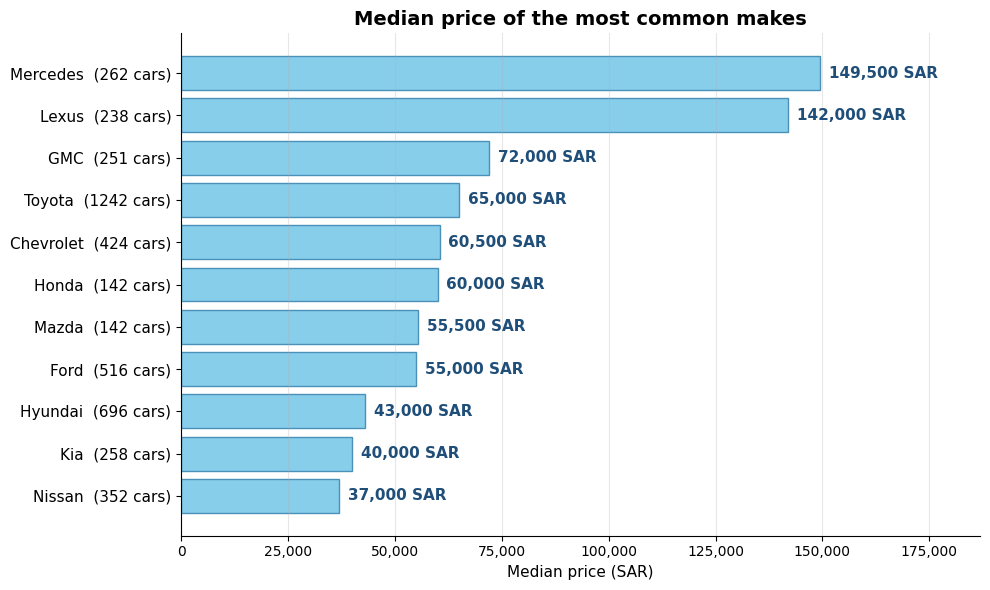

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# The most common makes (if several makes tie for 10th place, all of them are included)
counts = clean["Make"].value_counts()
cutoff = counts.iloc[9]
top_makes = counts[counts >= cutoff].index

summary = (clean[clean["Make"].isin(top_makes)]
           .groupby("Make")["Price"]
           .agg(cars="count", median_price="median", mean_price="mean")
           .sort_values("median_price", ascending=False)
           .round(0))
print("Makes shown:", len(summary))
print(summary)

# Draw from the smallest to the largest, so the most expensive make is on top
plot_data = summary.sort_values("median_price")
labels = [f"{make}  ({int(row.cars)} cars)" for make, row in plot_data.iterrows()]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(labels, plot_data["median_price"], color="skyblue", edgecolor="#4a90b8")

# Exact value at the end of each bar
for bar, value in zip(bars, plot_data["median_price"]):
    ax.text(value + 2000, bar.get_y() + bar.get_height() / 2,
            f"{int(value):,} SAR", va="center", fontsize=11, fontweight="bold", color="#1f4e79")

ax.set_title("Median price of the most common makes", fontsize=14, fontweight="bold")
ax.set_xlabel("Median price (SAR)", fontsize=11)
ax.set_xlim(0, plot_data["median_price"].max() * 1.25)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="x", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", labelsize=11)

plt.tight_layout()
plt.show()

## Chart 2: Median Price of the Most Common Makes | الرسم 2: وسيط السعر لأكثر الماركات انتشاراً

**How it was made | كيف انعمل**
- **EN:** We took the 10 makes with the most cars. Honda and Mazda tie in 10th place (142 cars each), so both are shown (11 makes). We used the **median** instead of the mean, because a few expensive cars pull the mean up (e.g. Mercedes: mean 175,689 SAR vs. median 149,500 SAR).
- **AR:** أخذنا أكثر 10 ماركات من ناحية عدد السيارات. Honda وMazda متعادلتين في المركز العاشر (142 سيارة لكل وحدة)، فعرضنا الاثنتين (11 ماركة). استخدمنا **الوسيط** بدل المتوسط، لأن قليل من السيارات الغالية يرفع المتوسط (مثلاً Mercedes: المتوسط 175,689 ريال مقابل الوسيط 149,500 ريال).

**Insights | الاستنتاجات**
1. **EN:** Mercedes (149,500 SAR) and Lexus (142,000 SAR) are far more expensive than the rest: about double the next make (GMC, 72,000 SAR) and about 4 times Nissan (37,000 SAR).
   **AR:** Mercedes (149,500 ريال) وLexus (142,000 ريال) أغلى بكثير من الباقي: تقريباً ضعف الماركة اللي بعدهم (GMC بـ 72,000 ريال) وحوالي 4 أضعاف Nissan (37,000 ريال).
2. **EN:** Six makes (GMC, Toyota, Chevrolet, Honda, Mazda, Ford) have close median prices, between 55,000 and 72,000 SAR, so the make alone does not separate them clearly.
   **AR:** ست ماركات (GMC وToyota وChevrolet وHonda وMazda وFord) أسعار وسيطها متقاربة بين 55,000 و72,000 ريال، فالماركة وحدها ما تفرق بينهم بوضوح.
3. **EN:** Toyota is the most common make in the data (1,242 cars, about 23%), with a median price of 65,000 SAR.
   **AR:** Toyota أكثر ماركة انتشاراً في البيانات (1,242 سيارة، حوالي 23%)، ووسيط سعرها 65,000 ريال.
4. **EN:** The cheapest makes are Nissan (37,000 SAR), Kia (40,000 SAR), and Hyundai (43,000 SAR).
   **AR:** أرخص الماركات Nissan (37,000 ريال) وKia (40,000 ريال) وHyundai (43,000 ريال).

**Limitation | الحد:** The make is not enough to explain the price. A make contains cheap and expensive models (e.g. Toyota Yaris and Land Cruiser), and the price also depends on year and mileage (next charts). | الماركة وحدها ما تفسر السعر. الماركة الواحدة فيها موديلات رخيصة وغالية (مثل Toyota Yaris وLand Cruiser)، والسعر يعتمد كمان على السنة والممشى (الرسوم الجاية).

Median price: 59,000 SAR | Mean price: 80,157 SAR


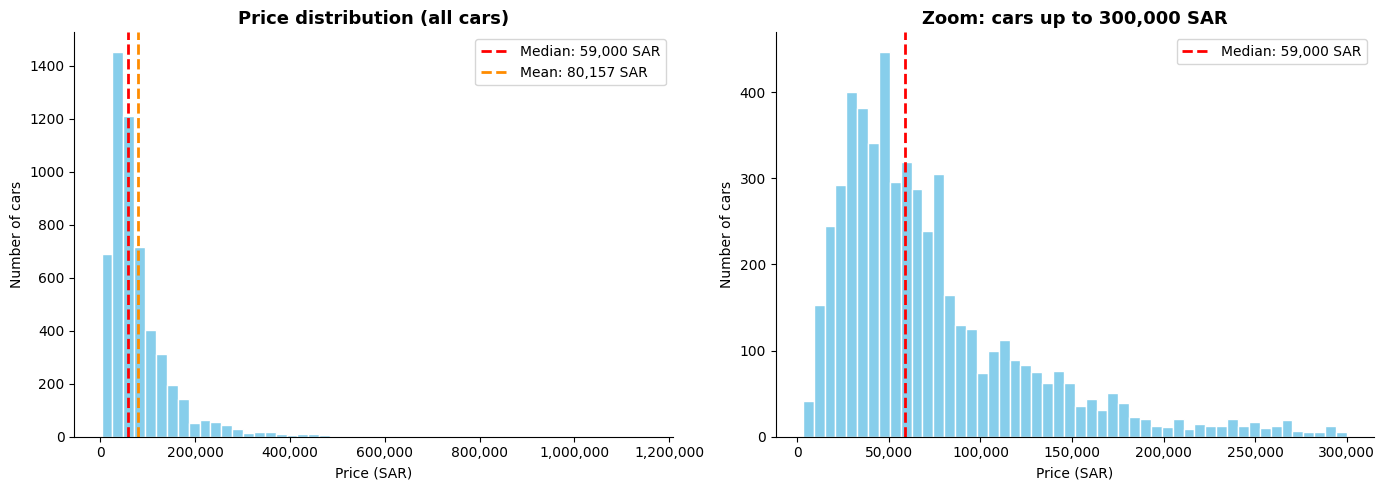

Cars above 300,000 SAR (not shown on the right): 112


In [ ]:
fmt = mticker.FuncFormatter(lambda x, _: f"{int(x):,}")

median_price = clean["Price"].median()
mean_price = clean["Price"].mean()
print(f"Median price: {median_price:,.0f} SAR | Mean price: {mean_price:,.0f} SAR")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all cars
axes[0].hist(clean["Price"], bins=50, color="skyblue", edgecolor="white")
axes[0].axvline(median_price, color="red", linestyle="--", linewidth=2, label=f"Median: {median_price:,.0f} SAR")
axes[0].axvline(mean_price, color="darkorange", linestyle="--", linewidth=2, label=f"Mean: {mean_price:,.0f} SAR")
axes[0].set_title("Price distribution (all cars)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Price (SAR)")
axes[0].set_ylabel("Number of cars")
axes[0].xaxis.set_major_formatter(fmt)
axes[0].legend()

# Right: zoom on cars up to 300,000 SAR
zoom = clean[clean["Price"] <= 300000]
axes[1].hist(zoom["Price"], bins=50, color="skyblue", edgecolor="white")
axes[1].axvline(median_price, color="red", linestyle="--", linewidth=2, label=f"Median: {median_price:,.0f} SAR")
axes[1].set_title("Zoom: cars up to 300,000 SAR", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Price (SAR)")
axes[1].set_ylabel("Number of cars")
axes[1].xaxis.set_major_formatter(fmt)
axes[1].legend()

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print("Cars above 300,000 SAR (not shown on the right):", (clean["Price"] > 300000).sum())

## Chart 1: Price Distribution | الرسم 1: توزيع الأسعار

**How to read it | كيف نقرأه**
- **EN:** Each bar is a price range and its height is the number of cars in that range. The left chart shows all 5,480 cars; the right chart zooms on cars priced up to 300,000 SAR, because a few very expensive cars stretch the left chart.
- **AR:** كل عمود يمثل نطاق أسعار، وطوله يمثل عدد السيارات في هذا النطاق. الرسم الأيسر لكل السيارات (5,480)، والأيمن تكبير على السيارات اللي سعرها 300,000 ريال وأقل، لأن قليل من السيارات الغالية جداً يمدد الرسم الأيسر.

**Key numbers | أهم الأرقام**

| | Value | القيمة |
|---|---|---|
| Median price | 59,000 SAR | الوسيط |
| Mean price | 80,157 SAR | المتوسط |
| Middle 50% of cars | 36,000 - 95,000 SAR | النصف الأوسط من السيارات |
| Minimum / Maximum | 3,000 / 1,150,000 SAR | أقل / أعلى سعر |
| Cars priced 100,000 SAR or less | 77% | السيارات بسعر 100,000 أو أقل |
| Cars above 300,000 SAR | 112 (2%) | السيارات فوق 300,000 |

**Insights | الاستنتاجات**
1. **EN:** The typical car costs about 59,000 SAR (the median). The most common range is 30,000-40,000 SAR (637 cars, about 12%), and 77% of the cars cost 100,000 SAR or less.
   **AR:** السيارة المعتادة سعرها حوالي 59,000 ريال (الوسيط). والنطاق الأكثر تكراراً من 30,000 إلى 40,000 ريال (637 سيارة، حوالي 12%)، و77% من السيارات سعرها 100,000 ريال أو أقل.
2. **EN:** The distribution is skewed to the right: most cars are cheap and a long tail of expensive cars reaches 1,150,000 SAR.
   **AR:** التوزيع منحرف لليمين: أغلب السيارات رخيصة، وفيه ذيل طويل من السيارات الغالية يوصل إلى 1,150,000 ريال.
3. **EN:** The mean (80,157 SAR) is about 36% higher than the median because the expensive cars pull it up. 68% of the cars cost less than the mean, so the median describes a typical car better.
   **AR:** المتوسط (80,157 ريال) أعلى من الوسيط بحوالي 36% لأن السيارات الغالية ترفعه. و68% من السيارات أرخص من المتوسط، فالوسيط يصف السيارة المعتادة بشكل أفضل.

**Idea for the model | فكرة للنموذج:** Because of the long tail, a few expensive cars may cause large prediction errors. We will test predicting `log(Price)` instead of `Price` and compare the results. | بسبب الذيل الطويل، قليل من السيارات الغالية ممكن يسبب أخطاء كبيرة في التوقع. بنجرب توقع `log(Price)` بدل `Price` ونقارن النتائج.

      cars  median_price
Year                    
2001    23       13500.0
2002    21       13000.0
2003    28       17250.0
2004    28       18250.0
2005    45       19000.0
2006    80       20000.0
2007    88       27000.0
2008   102       28000.0
2009   102       32000.0
2010   129       30000.0
2011   163       36000.0
2012   191       41500.0
2013   316       50000.0
2014   345       52000.0
2015   581       65000.0
2016   880       68000.0
2017   632       64250.0
2018   625       70000.0
2019   507       72000.0
2020   387      110000.0
2021   115      145000.0


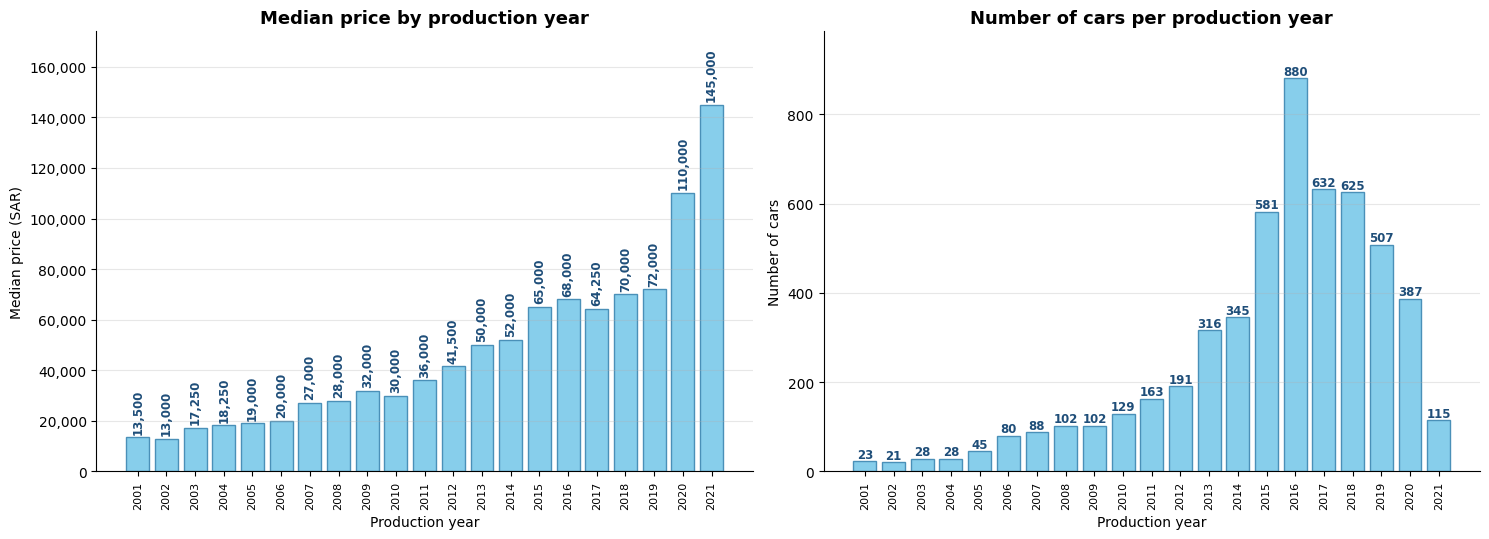

In [ ]:
fmt = mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
MIN_CARS = 20   # show only years with at least this many cars

by_year = clean.groupby("Year")["Price"].agg(cars="count", median_price="median")
by_year = by_year[by_year["cars"] >= MIN_CARS]
print(by_year.round(0).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: median price for each year
bars = axes[0].bar(by_year.index, by_year["median_price"], color="skyblue", edgecolor="#4a90b8")
for bar, v in zip(bars, by_year["median_price"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 1500, f"{int(v):,}",
                 ha="center", va="bottom", rotation=90, fontsize=8.5, fontweight="bold", color="#1f4e79")
axes[0].set_title("Median price by production year", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Production year")
axes[0].set_ylabel("Median price (SAR)")
axes[0].yaxis.set_major_formatter(fmt)
axes[0].set_xticks(by_year.index)
axes[0].tick_params(axis="x", labelsize=8, rotation=90)
axes[0].set_ylim(0, by_year["median_price"].max() * 1.2)

# Right: number of cars in each year
bars = axes[1].bar(by_year.index, by_year["cars"], color="skyblue", edgecolor="#4a90b8")
for bar, v in zip(bars, by_year["cars"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 8, f"{int(v)}",
                 ha="center", fontsize=8.5, fontweight="bold", color="#1f4e79")
axes[1].set_title("Number of cars per production year", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Production year")
axes[1].set_ylabel("Number of cars")
axes[1].set_xticks(by_year.index)
axes[1].tick_params(axis="x", labelsize=8, rotation=90)
axes[1].set_ylim(0, by_year["cars"].max() * 1.12)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Median mileage of the newest cars
print(clean[clean["Year"].isin([2019, 2020, 2021])].groupby("Year")["Mileage"].median())

Year
2019    58428.0
2020    19400.0
2021     4000.0
Name: Mileage, dtype: float64


## Chart 3: Price by Production Year | الرسم 3: السعر حسب سنة الصنع

**How to read it | كيف نقرأه**
- **EN:** The left chart shows the median price of each production year; the right chart shows how many cars we have per year. Only years with at least 20 cars are shown (2001-2021, 5,388 cars); the 92 cars from 1990-2000 are not shown because each of those years has fewer than 20 cars.
- **AR:** الرسم الأيسر يعرض وسيط السعر لكل سنة صنع، والأيمن يعرض عدد السيارات في كل سنة. عرضنا السنوات اللي فيها 20 سيارة أو أكثر فقط (2001 إلى 2021، 5,388 سيارة)، والـ 92 سيارة من 1990 إلى 2000 ما ظهرت لأن كل سنة منها فيها أقل من 20 سيارة.

**Key numbers | أهم الأرقام**

| Production year | Cars | Median price (SAR) |
|---|---|---|
| 2001 | 23 | 13,500 |
| 2010 | 129 | 30,000 |
| 2015 | 581 | 65,000 |
| 2019 | 507 | 72,000 |
| 2020 | 387 | 110,000 |
| 2021 | 115 | 145,000 |

**Insights | الاستنتاجات**
1. **EN:** Newer cars cost more. The median price rises from 13,500 SAR (2001) to 145,000 SAR (2021), about 10.7 times. Between 2010 and 2019 it more than doubles (30,000 to 72,000 SAR).
   **AR:** السيارات الأحدث أغلى. وسيط السعر يرتفع من 13,500 ريال (2001) إلى 145,000 ريال (2021)، حوالي 10.7 أضعاف. وبين 2010 و2019 يتضاعف أكثر من مرتين (من 30,000 إلى 72,000 ريال).
2. **EN:** There is a sharp jump for 2020-2021: from 72,000 SAR (2019) to 110,000 SAR (2020, +53%) and 145,000 SAR (2021). These cars are almost new: their median mileage is 19,400 km (2020) and 4,000 km (2021), compared to 58,428 km for 2019 cars.
   **AR:** فيه قفزة واضحة في 2020 و2021: من 72,000 ريال (2019) إلى 110,000 ريال (2020، +53%) و145,000 ريال (2021). هذي السيارات شبه جديدة: وسيط ممشاها 19,400 كم (2020) و4,000 كم (2021)، مقابل 58,428 كم لموديلات 2019.
3. **EN:** The rise is not perfectly regular (e.g. 2010 is below 2009, and 2017 is below 2016), because each year contains a different mix of makes and models.
   **AR:** الزيادة مو منتظمة تماماً (مثلاً 2010 أقل من 2009، و2017 أقل من 2016)، لأن كل سنة فيها خليط مختلف من الماركات والموديلات.
4. **EN:** Most cars in the data are from 2015-2019 (3,225 cars, 59%). The peak is 2016 with 880 cars (16%). Only 115 cars are from 2021.
   **AR:** أغلب السيارات في البيانات موديلات 2015 إلى 2019 (3,225 سيارة، 59%). وأعلى سنة 2016 بـ 880 سيارة (16%). وسيارات 2021 فقط 115.

**Limitations | الحدود**
- **EN:** The median of each year mixes different makes and models, so the year alone does not fully explain the price. Old years (2001-2004) have only 21-28 cars each, so their medians are less reliable.
- **AR:** وسيط كل سنة يخلط ماركات وموديلات مختلفة، فالسنة وحدها ما تفسر السعر بالكامل. والسنوات القديمة (2001 إلى 2004) فيها 21 إلى 28 سيارة بس لكل سنة، فوسيطها أقل موثوقية.

**Idea for the model | فكرة للنموذج:** The price does not grow in a straight line (it bends upward for 2020-2021), while Linear Regression assumes a straight line, so it may under-predict the newest cars. Another reason to test `log(Price)`. | السعر ما يرتفع بخط مستقيم (ينحني لفوق في 2020 و2021)، وLinear Regression يفترض خط مستقيم، فممكن يقلل من توقع أسعار السيارات الأحدث. سبب ثاني نجرب `log(Price)`.

Correlation Price vs Year: 0.35
Correlation Price vs Mileage: -0.35
Correlation Year vs Mileage: -0.6
Cars above 400,000 SAR (not shown on the left): 49
          cars  median_price
Mileage                     
<30k       649      103000.0
30-60k     571       85000.0
60-100k   1052       70000.0
100-150k  1116       61500.0
150-200k   694       52000.0
200-300k   842       43000.0
300k+      556       32000.0


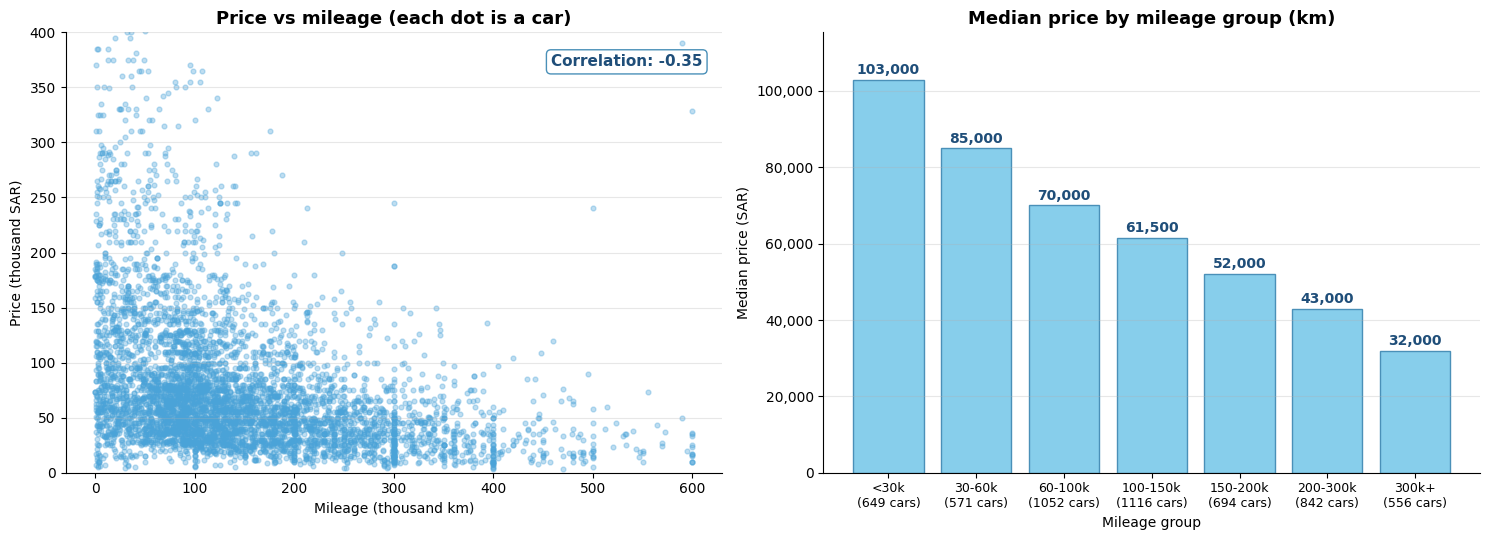

In [ ]:
fmt = mticker.FuncFormatter(lambda x, _: f"{int(x):,}")

# Correlations (-1 to 1: how strongly two columns move together)
corr_year = clean["Price"].corr(clean["Year"])
corr_mileage = clean["Price"].corr(clean["Mileage"])
print("Correlation Price vs Year:", round(corr_year, 2))
print("Correlation Price vs Mileage:", round(corr_mileage, 2))
print("Correlation Year vs Mileage:", round(clean["Year"].corr(clean["Mileage"]), 2))
print("Cars above 400,000 SAR (not shown on the left):", (clean["Price"] > 400000).sum())

# Median price for each mileage group
bins = [-1, 29999, 59999, 99999, 149999, 199999, 299999, 600000]
labels = ["<30k", "30-60k", "60-100k", "100-150k", "150-200k", "200-300k", "300k+"]
mileage_group = pd.cut(clean["Mileage"], bins=bins, labels=labels)
by_mileage = clean.groupby(mileage_group, observed=True)["Price"].agg(cars="count", median_price="median")
print(by_mileage.round(0))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: one dot per car (prices above 400,000 are cut to keep the chart readable)
axes[0].scatter(clean["Mileage"] / 1000, clean["Price"] / 1000, alpha=0.35, s=12, color="#4aa3d8")
axes[0].set_ylim(0, 400)
axes[0].set_title("Price vs mileage (each dot is a car)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Mileage (thousand km)")
axes[0].set_ylabel("Price (thousand SAR)")
axes[0].text(0.97, 0.95, f"Correlation: {corr_mileage:.2f}", transform=axes[0].transAxes,
             ha="right", va="top", fontsize=11, fontweight="bold", color="#1f4e79",
             bbox=dict(boxstyle="round", facecolor="white", edgecolor="#4a90b8"))

# Right: median price for each mileage group
xlabels = [f"{g}\n({int(c)} cars)" for g, c in zip(by_mileage.index.astype(str), by_mileage["cars"])]
bars = axes[1].bar(xlabels, by_mileage["median_price"], color="skyblue", edgecolor="#4a90b8")
for bar, v in zip(bars, by_mileage["median_price"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 1500, f"{int(v):,}",
                 ha="center", fontsize=10, fontweight="bold", color="#1f4e79")
axes[1].set_title("Median price by mileage group (km)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Mileage group")
axes[1].set_ylabel("Median price (SAR)")
axes[1].yaxis.set_major_formatter(fmt)
axes[1].tick_params(axis="x", labelsize=9)
axes[1].set_ylim(0, by_mileage["median_price"].max() * 1.12)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 1) Cars with more than 200,000 km: how many cost 100,000 SAR or less?
high = clean[clean["Mileage"] > 200000]
print("Cars above 200,000 km:", len(high), "| share priced 100,000 SAR or less:", round((high["Price"] <= 100000).mean() * 100, 1), "%")

# 2) Does mileage still matter for cars of a similar age? (production years 2015-2018 only)
same_years = clean[(clean["Year"] >= 2015) & (clean["Year"] <= 2018)]
groups = pd.cut(same_years["Mileage"], [-1, 59999, 99999, 149999, 199999, 600000], labels=["<60k", "60-100k", "100-150k", "150-200k", "200k+"])
print(same_years.groupby(groups, observed=True)["Price"].agg(cars="count", median_price="median"))

# 3) How many mileage values are round numbers (multiples of 10,000 km)?
print("Mileage values that are multiples of 10,000 km:", round((clean["Mileage"] % 10000 == 0).mean() * 100, 1), "%")

Cars above 200,000 km: 1335 | share priced 100,000 SAR or less: 94.2 %
          cars  median_price
Mileage                     
<60k       384       85000.0
60-100k    737       74500.0
100-150k   821       65000.0
150-200k   407       60000.0
200k+      369       58000.0
Mileage values that are multiples of 10,000 km: 20.3 %


## Chart 4: Price vs Mileage | الرسم 4: السعر مقابل الممشى

**How to read it | كيف نقرأه**
- **EN:** The left chart shows one dot per car (prices above 400,000 SAR are cut; 49 cars). The right chart groups the cars by mileage and shows the median price of each group. The correlation is a number between -1 and 1: a negative value means that when one column goes up, the other goes down.
- **AR:** الرسم الأيسر نقطة لكل سيارة (قطعنا الأسعار فوق 400,000 ريال، وعددها 49 سيارة). الرسم الأيمن يقسم السيارات حسب الممشى ويعرض وسيط السعر لكل فئة. الـ Correlation رقم من -1 إلى 1: القيمة السالبة معناها إن لما عمود يزيد الثاني ينزل.

**Key numbers | أهم الأرقام**

| Mileage group (km) | Cars | Median price (SAR) | فئة الممشى |
|---|---|---|---|
| Under 30k | 649 | 103,000 | أقل من 30 ألف |
| 30-60k | 571 | 85,000 | |
| 60-100k | 1,052 | 70,000 | |
| 100-150k | 1,116 | 61,500 | |
| 150-200k | 694 | 52,000 | |
| 200-300k | 842 | 43,000 | |
| 300k+ | 556 | 32,000 | 300 ألف فأكثر |

| Correlation | Value |
|---|---|
| Price vs Mileage | -0.35 |
| Price vs Year | 0.35 |
| Year vs Mileage | -0.60 |

**Insights | الاستنتاجات**
1. **EN:** Higher mileage means lower price. The median falls from 103,000 SAR (under 30,000 km) to 32,000 SAR (300,000 km and above), so high-mileage cars cost about 31% of low-mileage cars. Each group is 12% to 26% cheaper than the previous one.
   **AR:** كل ما زاد الممشى نزل السعر. الوسيط ينزل من 103,000 ريال (أقل من 30,000 كم) إلى 32,000 ريال (300,000 كم فأكثر)، يعني سيارات الممشى العالي سعرها حوالي 31% من سعر قليلة الممشى. وكل فئة أرخص من اللي قبلها بين 12% و26%.
2. **EN:** The relationship is moderate, not strong (correlation -0.35). The left chart is a cloud, not a line: mileage alone does not explain the price, because make and model matter a lot.
   **AR:** العلاقة متوسطة مو قوية (Correlation -0.35). الرسم الأيسر غيمة مو خط: الممشى وحده ما يفسر السعر، لأن الماركة والموديل يلعبون دور كبير.
3. **EN:** Most cars with very high mileage are cheap: of the 1,335 cars above 200,000 km, 94% cost 100,000 SAR or less.
   **AR:** أغلب السيارات كثيرة الممشى رخيصة: من 1,335 سيارة ممشاها فوق 200,000 كم، 94% سعرها 100,000 ريال أو أقل.
4. **EN:** Mileage and year are related (correlation -0.60): newer cars have lower mileage. So part of the price drop comes from age. For cars from 2015-2018 only, the median price falls from 85,000 SAR (under 60,000 km) to 58,000 SAR (above 200,000 km), about -32% instead of -69%. Mileage still matters at the same age, but less than it first appears.
   **AR:** الممشى والسنة مرتبطين (Correlation -0.60): السيارات الأحدث ممشاها أقل. فجزء من نزول السعر سببه العمر. وفي موديلات 2015 إلى 2018 فقط، وسيط السعر ينزل من 85,000 ريال (أقل من 60,000 كم) إلى 58,000 ريال (فوق 200,000 كم)، حوالي -32% بدل -69%. الممشى يفرق حتى بنفس العمر، لكن أقل مما يبدو أول.

**Limitations | الحدود**
- **EN:** A correlation shows a relationship, not a cause. The median of each group mixes different makes and years. Mileage is often rounded by the sellers: about 20% of the values are multiples of 10,000 km.
- **AR:** الـ Correlation يوضح علاقة مو سبب. ووسيط كل فئة يخلط ماركات وسنوات مختلفة. والممشى غالباً مقرّب من أصحاب الإعلانات: حوالي 20% من القيم مضاعفات لـ 10,000 كم.

**Idea for the model | فكرة للنموذج:** Year and mileage explain overlapping parts of the price, so we will use both together with the make. | السنة والممشى يشرحون أجزاء متداخلة من السعر، فنستخدمهم مع بعض ومع الماركة.

Regions in the data: 27
Regions shown: 8 | cars covered: 4960 of 5480
           cars  median_price  mean_price
Region                                   
Dammam     1138       69000.0     93659.0
Riyadh     2301       61000.0     82950.0
Qassim      157       60000.0     74579.0
Aseer       123       58000.0     70106.0
Jeddah      781       55000.0     77099.0
Al-Ahsa     154       53000.0     67910.0
Al-Medina   172       45000.0     58900.0
Makkah      134       43000.0     68705.0
             Year   Mileage
Region                     
Al-Ahsa    2016.0  130500.0
Al-Medina  2014.0  141500.0
Aseer      2015.0  144000.0
Dammam     2016.0  109596.0
Jeddah     2016.0  110000.0
Makkah     2014.0  163200.0
Qassim     2016.0  107921.0
Riyadh     2016.0  109000.0


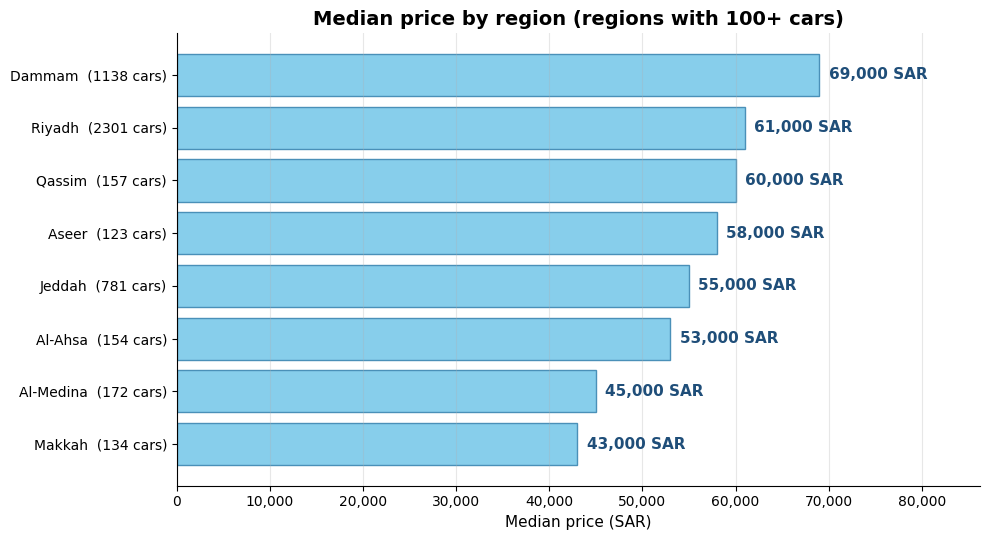

In [ ]:
MIN_CARS = 100   # show only regions with at least this many cars

by_region = (clean.groupby("Region")["Price"]
             .agg(cars="count", median_price="median", mean_price="mean")
             .sort_values("cars", ascending=False))
shown = by_region[by_region["cars"] >= MIN_CARS].sort_values("median_price", ascending=False)

print("Regions in the data:", len(by_region))
print("Regions shown:", len(shown), "| cars covered:", shown["cars"].sum(), "of", len(clean))
print(shown.round(0))

# Typical age and mileage of the cars in each region (to understand the differences)
print(clean[clean["Region"].isin(shown.index)].groupby("Region")[["Year", "Mileage"]].median().round(0))

# Draw from the smallest to the largest, so the most expensive region is on top
plot_data = shown.sort_values("median_price")
labels = [f"{region}  ({int(row.cars)} cars)" for region, row in plot_data.iterrows()]

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(labels, plot_data["median_price"], color="skyblue", edgecolor="#4a90b8")
for bar, value in zip(bars, plot_data["median_price"]):
    ax.text(value + 1000, bar.get_y() + bar.get_height() / 2,
            f"{int(value):,} SAR", va="center", fontsize=11, fontweight="bold", color="#1f4e79")

ax.set_title("Median price by region (regions with 100+ cars)", fontsize=14, fontweight="bold")
ax.set_xlabel("Median price (SAR)", fontsize=11)
ax.set_xlim(0, plot_data["median_price"].max() * 1.25)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="x", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Chart 5 (Optional): Price by Region | الرسم 5 (اختياري): السعر حسب المنطقة

**How it was made | كيف انعمل**
- **EN:** The data has 27 regions. We show the 8 regions with at least 100 cars (4,960 of 5,480 cars, about 90%), because the median of a small group is not reliable.
- **AR:** البيانات فيها 27 منطقة. عرضنا 8 مناطق فيها 100 سيارة أو أكثر (4,960 من 5,480 سيارة، حوالي 90%)، لأن وسيط المجموعة الصغيرة غير موثوق.

**Key numbers | أهم الأرقام**

| Region | Cars | Median price (SAR) |
|---|---|---|
| Dammam | 1,138 | 69,000 |
| Riyadh | 2,301 | 61,000 |
| Qassim | 157 | 60,000 |
| Aseer | 123 | 58,000 |
| Jeddah | 781 | 55,000 |
| Al-Ahsa | 154 | 53,000 |
| Al-Medina | 172 | 45,000 |
| Makkah | 134 | 43,000 |

**Insights | الاستنتاجات**
1. **EN:** Riyadh has the most listings (2,301 cars, about 42%). Riyadh, Dammam, and Jeddah together make about 77% of the cars.
   **AR:** الرياض فيها أكثر إعلانات (2,301 سيارة، حوالي 42%). والرياض والدمام وجدة مع بعض حوالي 77% من السيارات.
2. **EN:** Dammam has the highest median price (69,000 SAR) and Makkah the lowest (43,000 SAR): Dammam is about 60% higher.
   **AR:** الدمام أعلى وسيط سعر (69,000 ريال) ومكة أقل وسيط (43,000 ريال): الدمام أعلى بحوالي 60%.
3. **EN:** Part of the difference comes from the type of cars, not only the location: cars in Makkah and Al-Medina are older (median year 2014 vs. 2016 in Riyadh and Dammam) and have higher mileage (163,200 and 141,500 km vs. about 109,000 km).
   **AR:** جزء من الفرق سببه نوع السيارات مو المنطقة وحدها: سيارات مكة والمدينة أقدم (وسيط السنة 2014 مقابل 2016 في الرياض والدمام) وممشاها أعلى (163,200 و141,500 كم مقابل حوالي 109,000 كم).

**Limitation | الحد:** Region is not one of the model inputs (make, year, mileage). This chart is for exploration only, and the regional differences also mix different makes. | المنطقة ليست من مدخلات النموذج (الماركة والسنة والممشى). هذا الرسم للاستكشاف فقط، والفروق بين المناطق تخلط ماركات مختلفة.

#**5. The region | المنطقة**
- **EN:** Riyadh has the most listings (about 42%). Dammam has the highest median price (69,000 SAR) and Makkah the lowest (43,000 SAR), partly because cars in Makkah and Al-Medina are older and have higher mileage. Region is used for exploration only, not as a model input.
- **AR:** الرياض فيها أكثر إعلانات (حوالي 42%). والدمام أعلى وسيط سعر (69,000 ريال) ومكة أقل وسيط (43,000 ريال)، وجزء من السبب إن سيارات مكة والمدينة أقدم وممشاها أعلى. المنطقة للاستكشاف فقط، مو من مدخلات النموذج.

In [ ]:
import os
import glob
import pandas as pd
from google.colab import drive

# Connect Google Drive (click Allow the first time)
drive.mount("/content/drive")

FILE_NAME = "used_cars_clean_v2.csv"
EXPECTED_SHAPE = (5480, 6)

# Look in the project folder first, then search all of Drive if needed
CLEAN_PATH = "/content/drive/MyDrive/My Project/" + FILE_NAME
if not os.path.exists(CLEAN_PATH):
    found = glob.glob("/content/drive/MyDrive/**/" + FILE_NAME, recursive=True)
    if found:
        CLEAN_PATH = found[0]
    else:
        raise FileNotFoundError(FILE_NAME + " was not found in your Google Drive.")

# Load the clean data
clean = pd.read_csv(CLEAN_PATH)
print("File used:", CLEAN_PATH)
print("Loaded:", clean.shape)

# Quick check that the data is what we expect
if clean.shape != EXPECTED_SHAPE:
    print("WARNING: the shape is different from", EXPECTED_SHAPE, ". Send me this output before continuing.")
else:
    print("OK: the clean data is ready.")

Mounted at /content/drive
File used: /content/drive/MyDrive/My Project/used_cars_clean_v2.csv
Loaded: (5480, 6)
OK: the clean data is ready.


## Step 6: Building the Model | الخطوة 6: بناء النموذج

**What this phase is about | عن هذي المرحلة**
- **EN:** Until now, we cleaned the data and explored it with charts. In this phase, we teach a model to predict a car's price from its Make, Year, and Mileage. The model looks at thousands of real cars and learns the relationship between these three factors and the price, then we test how accurate its predictions are on cars it has not seen before.
- **AR:** لين الحين نظفنا البيانات واستكشفناها بالرسوم. في هذي المرحلة، نعلّم نموذج يتوقع سعر السيارة من الماركة والسنة والممشى. النموذج يشوف آلاف السيارات الحقيقية ويتعلم العلاقة بين هذي العوامل الثلاثة والسعر، وبعدها نختبر دقة توقعاته على سيارات ما شافها من قبل.

**What we will do, in order | الخطوات بالترتيب**
1. **EN:** Prepare the inputs (Make, Year, Mileage) and the target (Price), and convert Make into numbers the model can understand. **AR:** نجهز المدخلات (الماركة والسنة والممشى) والهدف (السعر)، ونحول الماركة إلى أرقام يفهمها النموذج.
2. **EN:** Split the data into 80% for training and 20% for testing, so we can check the model on cars it never saw (`random_state=103`). **AR:** نقسم البيانات إلى 80% للتدريب و20% للاختبار، عشان نتأكد من النموذج على سيارات ما شافها إطلاقاً (`random_state=103`).
3. **EN:** Train a Linear Regression model on the training data. **AR:** ندرب نموذج Linear Regression على بيانات التدريب.
4. **EN:** Measure its accuracy on the test data (MAE and R²). **AR:** نقيس دقته على بيانات الاختبار (MAE وR²).
5. **EN:** Try predicting `log(Price)` instead of `Price` and compare the results, because of the long tail of expensive cars we saw in Chart 1. **AR:** نجرب توقع `log(Price)` بدل `Price` ونقارن النتائج، بسبب الذيل الطويل للسيارات الغالية اللي شفناه في الرسم 1.
6. **EN:** Build the `predict_price(brand, year, mileage)` function so anyone can enter a car's details and get an estimated price. **AR:** نبني دالة `predict_price(brand, year, mileage)` عشان أي شخص يدخل مواصفات سيارة ويحصل على سعر متوقع.

**Why Linear Regression | ليش Linear Regression:** It predicts a continuous number (price) from several factors, it is simple enough to explain in the presentation, and it fits the time and scope of this project. | يتوقع رقم مستمر (السعر) من عدة عوامل، وبسيط بما يكفي نشرحه بالعرض، ويناسب وقت المشروع وحجمه.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Inputs (X) and what we want to predict (y)
X = pd.get_dummies(clean[["Make", "Year", "Mileage"]], columns=["Make"], dtype=int)
y = clean["Price"]

print("Number of makes:", clean["Make"].nunique())
print("X shape:", X.shape, "| y shape:", y.shape)

# Split: 80% for training, 20% for testing (random_state makes the split repeatable)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=103)
print("Training cars:", X_train.shape[0], "| Test cars:", X_test.shape[0])

Number of makes: 61
X shape: (5480, 63) | y shape: (5480,)
Training cars: 4384 | Test cars: 1096


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Train the model on the training data
model = LinearRegression()
model.fit(X_train, y_train)

# Test it on cars it has never seen
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"MAE (average error): {mae:,.0f} SAR")
print(f"R² (how well the model explains the price): {r2:.2f}")

MAE (average error): 32,985 SAR
R² (how well the model explains the price): 0.51


## Model Result 1: Linear Regression on Price | نتيجة النموذج 1: Linear Regression على السعر مباشرة

**EN:** The model was trained on 4,384 cars and tested on 1,096 cars it never saw. Result: **MAE = 32,985 SAR** (the average prediction error) and **R² = 0.51** (the model explains about 51% of the price variation). This is moderate, not excellent, because the model uses only 3 inputs (Make, Year, Mileage) and the long tail of expensive cars (Chart 1) pulls the line and weakens predictions for typical cars.

**AR:** تدرب النموذج على 4,384 سيارة واختبرناه على 1,096 سيارة ما شافها إطلاقاً. النتيجة: **MAE = 32,985 ريال** (متوسط خطأ التوقع) و**R² = 0.51** (النموذج يفسر حوالي 51% من التغير في الأسعار). هذا معقول مو ممتاز، لأن النموذج يستخدم 3 مدخلات بس (الماركة والسنة والممشى)، والذيل الطويل للسيارات الغالية (الرسم 1) يشد الخط ويضعف التوقعات للسيارات العادية.

**Next | التالي:** Try predicting `log(Price)` instead, to reduce the effect of expensive cars. | نجرب توقع `log(Price)` بدلاً منه، لتقليل تأثير السيارات الغالية.

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Train on log(Price) instead of Price directly
model_log = LinearRegression()
model_log.fit(X_train, np.log(y_train))

# Predict, then convert back from log scale to real SAR
predictions_log = np.exp(model_log.predict(X_test))

mae_log = mean_absolute_error(y_test, predictions_log)
r2_log = r2_score(y_test, predictions_log)

print(f"MAE with log(Price): {mae_log:,.0f} SAR")
print(f"R² with log(Price): {r2_log:.2f}")

print("\n--- Comparison ---")
print(f"Without log: MAE = {mae:,.0f} SAR | R² = {r2:.2f}")
print(f"With log:    MAE = {mae_log:,.0f} SAR | R² = {r2_log:.2f}")

MAE with log(Price): 28,921 SAR
R² with log(Price): 0.54

--- Comparison ---
Without log: MAE = 32,985 SAR | R² = 0.51
With log:    MAE = 28,921 SAR | R² = 0.54


## Model Result 2: Linear Regression on log(Price) | نتيجة النموذج 2: Linear Regression على log(Price)

**EN:** Same training and test cars, but the model learned `log(Price)` instead of `Price` directly, then predictions were converted back to SAR. Result: **MAE = 28,921 SAR** and **R² = 0.54**, both better than predicting the raw price (MAE = 32,985 SAR, R² = 0.51). The improvement (~12% lower error) confirms that the long tail of expensive cars was hurting the first model.

**AR:** نفس سيارات التدريب والاختبار، لكن النموذج تعلم `log(Price)` بدل `Price` مباشرة، وبعدها حولنا التوقعات رجوع لريالات. النتيجة: **MAE = 28,921 ريال** و**R² = 0.54**، أفضل من توقع السعر الخام (MAE = 32,985 ريال، R² = 0.51). التحسن (حوالي 12% أقل خطأ) يأكد إن الذيل الطويل للسيارات الغالية كان يأثر سلباً على النموذج الأول.

**Decision | القرار:** Use the log(Price) model for the `predict_price` function. | نستخدم نموذج log(Price) في دالة `predict_price`.

In [ ]:
def predict_price(brand, year, mileage):
    # Build one row with the same columns the model was trained on, all zeros
    input_row = pd.DataFrame(0, index=[0], columns=X.columns)
    input_row["Year"] = year
    input_row["Mileage"] = mileage

    make_column = "Make_" + brand
    if make_column not in X.columns:
        print(f"Warning: '{brand}' is not a make the model has seen. Try one of: {sorted(clean['Make'].unique())}")
        return None

    input_row[make_column] = 1

    predicted_log_price = model_log.predict(input_row)[0]
    predicted_price = np.exp(predicted_log_price)
    return round(predicted_price)

# Try it on a few cars
print(predict_price("Toyota", 2018, 80000), "SAR")
print(predict_price("Hyundai", 2020, 30000), "SAR")
print(predict_price("Mercedes", 2019, 50000), "SAR")

92688 SAR
61655 SAR
212602 SAR


## Step 7: The `predict_price` Function | الخطوة 7: دالة `predict_price`

**What it does | وش تسوي**
- **EN:** Takes a car's make, production year, and mileage, and returns the estimated price in SAR using the log(Price) model. It rebuilds the same input format the model was trained on (one column per make, set to 1 for the given make and 0 for the rest), predicts on the log scale, then converts back to SAR.
- **AR:** تاخذ ماركة السيارة وسنة الصنع والممشى، وترجع السعر المتوقع بالريال باستخدام نموذج log(Price). تبني نفس شكل المدخلات اللي تدرب عليها النموذج (عمود لكل ماركة، تحطه 1 للماركة المطلوبة و0 للباقي)، تتوقع على مقياس log، ثم تحول النتيجة رجوع لريالات.

**Test results | نتائج التجربة**

| Make | Year | Mileage | Predicted price |
|---|---|---|---|
| Toyota | 2018 | 80,000 | 92,688 SAR |
| Hyundai | 2020 | 30,000 | 61,655 SAR |
| Mercedes | 2019 | 50,000 | 212,602 SAR |

**EN:** All three predictions are consistent with the charts: each is higher than that make's overall median price (Chart 2), because these sample cars are newer and have lower mileage than the typical car in the data.
**AR:** التوقعات الثلاثة متسقة مع الرسوم: كل واحد أعلى من وسيط سعر ماركته العام (الرسم 2)، لأن هذي السيارات النموذجية أحدث وممشاها أقل من السيارة المعتادة في البيانات.

**Limitation | الحد:** If the make entered is not one of the 61 makes the model learned, the function prints a warning and returns nothing. | لو الماركة المدخلة مو من ضمن الـ 61 ماركة اللي تعلمها النموذج، الدالة تطبع تحذير وما ترجع شي.

**Update | تحديث:** After testing, we decided to add the car's specific model (Type) as a fourth input to improve accuracy further. See the next section. | بعد التجربة، قررنا نضيف موديل السيارة (Type) كمدخل رابع لتحسين الدقة أكثر. شوفي القسم اللي بعده.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Inputs now include Type (the specific model), not just Make
X_with_type = pd.get_dummies(clean[["Make", "Type", "Year", "Mileage"]], columns=["Make", "Type"], dtype=int)
y = clean["Price"]

print("Unique models (Type):", clean["Type"].nunique())
print("Models with only 1 car:", (clean["Type"].value_counts() == 1).sum())
print("X shape:", X_with_type.shape)

# Same split settings as before (random_state=103), so results are comparable
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_with_type, y, test_size=0.2, random_state=103)

model_with_type = LinearRegression()
model_with_type.fit(X_train_t, np.log(y_train_t))
predictions_t = np.exp(model_with_type.predict(X_test_t))

mae_t = mean_absolute_error(y_test_t, predictions_t)
r2_t = r2_score(y_test_t, predictions_t)

print(f"\nMAE with Make+Type+Year+Mileage: {mae_t:,.0f} SAR")
print(f"R² with Make+Type+Year+Mileage: {r2_t:.2f}")

Unique models (Type): 381
Models with only 1 car: 107
X shape: (5480, 444)

MAE with Make+Type+Year+Mileage: 14,686 SAR
R² with Make+Type+Year+Mileage: 0.83


In [ ]:
def predict_price(brand, model_type, year, mileage):
    # Build one row with the same columns the model was trained on, all zeros
    input_row = pd.DataFrame(0, index=[0], columns=X_with_type.columns)
    input_row["Year"] = year
    input_row["Mileage"] = mileage

    make_column = "Make_" + brand
    type_column = "Type_" + model_type

    if make_column not in X_with_type.columns:
        print(f"Warning: '{brand}' is not a make the model has seen.")
        return None
    if type_column not in X_with_type.columns:
        print(f"Warning: '{model_type}' is not a model the model has seen for any make.")
        return None

    # Check the combination actually exists in the data (avoids nonsense combinations)
    combo_exists = ((clean["Make"] == brand) & (clean["Type"] == model_type)).any()
    if not combo_exists:
        print(f"Warning: '{brand} {model_type}' combination was not seen in the data.")
        return None

    input_row[make_column] = 1
    input_row[type_column] = 1

    predicted_log_price = model_with_type.predict(input_row)[0]
    predicted_price = np.exp(predicted_log_price)
    return round(predicted_price)

# Try it on the same cars as before, now with a model name
print(predict_price("Toyota", "Corolla", 2018, 80000), "SAR")
print(predict_price("Hyundai", "Elantra", 2020, 30000), "SAR")
print(predict_price("Mercedes", "G", 2019, 50000), "SAR")

51232 SAR
60629 SAR
534050 SAR


## Model Result 3: Adding the Model (Type) | نتيجة النموذج 3: إضافة الموديل (Type)

**EN:** We added the car's specific model (Type) as a fourth input, alongside Make, Year, and Mileage, because a make alone (e.g. "Toyota") hides big price differences between models (e.g. Corolla vs. Land Cruiser). The data has 381 different models, and 107 of them have only 1 car, so predictions for rare models are less reliable.

**AR:** أضفنا موديل السيارة بالتحديد (Type) كمدخل رابع، بجانب الماركة والسنة والممشى، لأن الماركة وحدها (مثل "Toyota") تخفي فروقات كبيرة بالسعر بين الموديلات (مثل Corolla مقابل Land Cruiser). البيانات فيها 381 موديل مختلف، و107 منها فيه سيارة وحدة بس، فتوقعاتها أقل موثوقية.

**Result | النتيجة**

| Model | Inputs | MAE | R² |
|---|---|---|---|
| 1 | Make + Year + Mileage | 32,985 SAR | 0.51 |
| 2 (log) | Make + Year + Mileage (log price) | 28,921 SAR | 0.54 |
| 3 (final) | Make + Type + Year + Mileage (log price) | **14,686 SAR** | **0.83** |

**EN:** Adding the model cut the error by about 49% (from 28,921 to 14,686 SAR) and raised R² from 0.54 to 0.83. This is the final model used in the `predict_price` function.
**AR:** إضافة الموديل خفضت الخطأ بحوالي 49% (من 28,921 إلى 14,686 ريال) ورفعت R² من 0.54 إلى 0.83. هذا هو النموذج النهائي المستخدم في دالة `predict_price`.

**Test results | نتائج التجربة**

| Make | Type | Year | Mileage | Predicted | Similar cars (median, all years) |
|---|---|---|---|---|---|
| Toyota | Corolla | 2018 | 80,000 | 51,232 SAR | 44,750 SAR (n=126) |
| Hyundai | Elantra | 2020 | 30,000 | 60,629 SAR | 45,500 SAR (n=141) |
| Mercedes | G | 2019 | 50,000 | 534,050 SAR | 352,500 SAR (n=8) |

**EN:** The first two predictions are reasonable: both cars are newer and have lower mileage than the typical car of that model, so a higher price than the median makes sense. The Mercedes G prediction is higher and less certain, because only 8 cars of this model exist in the data — a good example of the model's limits with rare models.
**AR:** التوقعان الأولان منطقيان: كل سيارة أحدث وممشاها أقل من السيارة المعتادة لنفس الموديل، فسعر أعلى من الوسيط منطقي. توقع Mercedes G أعلى وأقل يقيناً، لأنه فيه 8 سيارات بس من هذا الموديل في البيانات — مثال جيد على حدود النموذج مع الموديلات النادرة.

**Limitations | الحدود**
- **EN:** The user must type the model name exactly as it appears in the data (e.g. "Corolla", not "corolla" or "كورولا"). Predictions for models with very few cars (many have fewer than 5) are less reliable.
- **AR:** المستخدم لازم يكتب اسم الموديل بالضبط زي ما هو بالبيانات (مثل "Corolla" مو "corolla" أو "كورولا"). توقعات الموديلات القليلة العدد (كثير منها أقل من 5 سيارات) أقل موثوقية.

In [ ]:
import joblib

# Save the trained model and the column structure it expects
joblib.dump(model_with_type, "car_price_model.pkl")
joblib.dump(X_with_type.columns, "model_columns.pkl")

# Download both files to your computer
from google.colab import files
files.download("car_price_model.pkl")
files.download("model_columns.pkl")

print("Saved and downloading: car_price_model.pkl and model_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloading: car_price_model.pkl and model_columns.pkl


In [ ]:
print(clean.shape)

(5480, 6)


In [ ]:
from google.colab import files

# Download the clean data directly to your computer
clean.to_csv("used_cars_clean_v2.csv", index=False)
files.download("used_cars_clean_v2.csv")

print("Downloading used_cars_clean_v2.csv...")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>